# Feature Selection — Cross-Validation-Based Selection

Same six strategies as `feature_selection_validation.ipynb` (RFE x2, RFECV x2,
L1-path, SelectKBest, Forward SFS x2, Tree importance), but feature selection
now uses **`CV_FOLDS`-fold stratified cross-validation on the pooled
train+val set** instead of a single held-out validation split.

**The test set is still never touched anywhere except the final cell.**

Split: `split_json_020726.json`. `train` and `val` are combined into one CV
pool; `test` is held out exactly as before. Cross-validated (out-of-fold)
metrics over the pool drive every k-selection decision.


## Imports

In [1]:
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import (
    RFE, RFECV,
    SelectFromModel,
    SelectKBest, f_classif,
)
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    matthews_corrcoef, roc_auc_score, f1_score,
    precision_recall_curve, auc, roc_curve,
    classification_report,
)

SEED = 42


## Configuration

In [2]:
HOMODIMERS_CSV = "/path/to/homodimers_logreg_features.csv"
SPLIT_JSON     = "train_test_split.json"

DROP_COLS = [
    "ID", "category", "correct_result",
    "highest_match_all_hits", "highest_match_multimers", "highest_match_homomultimers",
    "stoich_all_hits", "stoich_multimers",
    "missing_foldseek", "missing_fraction_buried", "missing_highest_match_hm",
    "highest_match_homodimers", "missing_highest_match_hd",
]

# ── Cross-validation ────────────────────────────────────────────────────────
# Number of stratified folds used everywhere below to score a feature subset
# (out-of-fold predictions over the pooled train+val set). Lower this if the
# exhaustive comparison cell takes too long to run.
CV_FOLDS = 5

# ── Homology / Foldseek feature toggle ────────────────────────────────────────
# This notebook is meant to be run TWICE: once with this False, once with it
# True -- Restart Kernel + Run All each time. Each pass's exhaustive-sweep
# cell saves its results to disk (cv_sweep_with_homology.pkl /
# cv_sweep_without_homology.pkl); the final cell loads BOTH so it can compare
# the best "with homology" and "without homology" subsets side by side,
# instead of relying on a hand-copied feature list.
EXCLUDE_HOMOLOGY_FEATURES = False

HOMOLOGY_PREFIXES = ("multimer_frac_tm", "hm_frac_tm", "highest_tm_")
# Engineered features derived from the raw homology columns above -- excluding
# them here too so a "without homology" pass can't leak homology signal back
# in through a derived column.
HOMOLOGY_EXTRA_COLS = ("foldseek_specificity", "hm_low_high_gap",
                       "hm_minus_multimer_tm08", "hm_high_any")

def is_homology_feature(col):
    return col.startswith(HOMOLOGY_PREFIXES) or col in HOMOLOGY_EXTRA_COLS


## Load data and split

In [3]:
df = pd.read_csv(HOMODIMERS_CSV)

df["iptm_spread"]     = df["avg_iptm"]  - df["min_iptm"]
df["rc_spread"]       = df["avg_rc"]    - df["min_rc"]
df["iptm_rc_prod"]    = df["min_iptm"]  * df["min_rc"]
df["ipsae_iptm_diff"] = df["avg_ipsae"] - df["avg_iptm"]
df["hm_minus_multimer_tm08"] = df["hm_frac_tm0.8"] - df["multimer_frac_tm0.8"]
df["hm_high_any"] = (df["hm_frac_tm0.8"] > 0).astype(int)
df["hm_low_high_gap"] = df["hm_frac_tm0.2"] - df["hm_frac_tm0.8"]
df["foldseek_specificity"] = df["hm_frac_tm0.8"] / (df["multimer_frac_tm0.8"] + 1e-6)

ALL_FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
if EXCLUDE_HOMOLOGY_FEATURES:
    ALL_FEATURE_COLS = [c for c in ALL_FEATURE_COLS if not is_homology_feature(c)]

K_VALUES = list(range(2, len(ALL_FEATURE_COLS)))   # RFE / SelectKBest sweep range

y = df["correct_result"].values

with open(SPLIT_JSON) as fh:
    _split = json.load(fh)

# train and val are POOLED for cross-validation; test is never loaded/used here.
train_mask    = df["ID"].isin(set(_split["train"])).values
# val_mask      = df["ID"].isin(set(_split["val"])).values
trainval_mask = train_mask #| val_mask

# NOTE: to reuse the RFE/RFECV/L1/KBest/ForwardSFS/Tree sweep code below almost
# verbatim from feature_selection_validation.ipynb, `Xtr_all` / `y_train` are
# bound here to the POOLED train+val data (not train-only). Every ranking step
# and every fit_and_eval_cv() call therefore operates on train+val combined;
# only the held-out test set (loaded in the final cell) is never touched.
y_train = y[trainval_mask]

X_all_pool = df[ALL_FEATURE_COLS].values[trainval_mask].astype(float)
scaler_all = StandardScaler()
Xtr_all    = scaler_all.fit_transform(X_all_pool)

print(f"Loaded {len(df)} rows, {len(ALL_FEATURE_COLS)} features "
      f"({'homology features EXCLUDED' if EXCLUDE_HOMOLOGY_FEATURES else 'homology features included'})")
# print(f"Train: {train_mask.sum()}  Val: {val_mask.sum()}  Pool (train+val): {trainval_mask.sum()}")
print(f"Train: {train_mask.sum()} Pool (train): {trainval_mask.sum()}")
print(f"Pool positives: {y_train.sum()}")
print(f"CV_FOLDS = {CV_FOLDS}")
print(f"\nFeatures ({len(ALL_FEATURE_COLS)}):")
for c in ALL_FEATURE_COLS:
    print(f"  {c}")


Loaded 2083 rows, 70 features (homology features included)
Train: 1249 Pool (train): 1249
Pool positives: 429
CV_FOLDS = 5

Features (70):
  min_ipsae
  max_ipsae
  avg_ipsae
  max_iptm
  min_iptm
  avg_iptm
  max_ptm
  min_ptm
  avg_ptm
  max_rc
  min_rc
  avg_rc
  multimer_frac_tm0.0
  multimer_frac_tm0.1
  multimer_frac_tm0.2
  multimer_frac_tm0.3
  multimer_frac_tm0.4
  multimer_frac_tm0.5
  multimer_frac_tm0.6
  multimer_frac_tm0.7
  multimer_frac_tm0.8
  multimer_frac_tm0.9
  hm_frac_tm0.0
  hm_frac_tm0.1
  hm_frac_tm0.2
  hm_frac_tm0.3
  hm_frac_tm0.4
  hm_frac_tm0.5
  hm_frac_tm0.6
  hm_frac_tm0.7
  hm_frac_tm0.8
  hm_frac_tm0.9
  highest_tm_all_hits
  highest_tm_multimers
  highest_tm_homomultimers
  num_contacts_with_max_n_models
  num_unique_contacts
  mean_contacts_across_predictions
  min_contacts_across_predictions
  best_num_residue_contacts
  best_if_residues
  best_plddt_max
  best_pae_min
  best_contact_score_max
  buried_apolar_area_mean
  buried_polar_area_mean
  to

In [4]:
df.columns

Index(['ID', 'category', 'correct_result', 'min_ipsae', 'max_ipsae',
       'avg_ipsae', 'max_iptm', 'min_iptm', 'avg_iptm', 'max_ptm', 'min_ptm',
       'avg_ptm', 'max_rc', 'min_rc', 'avg_rc', 'multimer_frac_tm0.0',
       'multimer_frac_tm0.1', 'multimer_frac_tm0.2', 'multimer_frac_tm0.3',
       'multimer_frac_tm0.4', 'multimer_frac_tm0.5', 'multimer_frac_tm0.6',
       'multimer_frac_tm0.7', 'multimer_frac_tm0.8', 'multimer_frac_tm0.9',
       'hm_frac_tm0.0', 'hm_frac_tm0.1', 'hm_frac_tm0.2', 'hm_frac_tm0.3',
       'hm_frac_tm0.4', 'hm_frac_tm0.5', 'hm_frac_tm0.6', 'hm_frac_tm0.7',
       'hm_frac_tm0.8', 'hm_frac_tm0.9', 'highest_match_all_hits',
       'highest_tm_all_hits', 'stoich_all_hits', 'highest_match_multimers',
       'highest_tm_multimers', 'stoich_multimers',
       'highest_match_homomultimers', 'highest_tm_homomultimers',
       'num_contacts_with_max_n_models', 'num_unique_contacts',
       'mean_contacts_across_predictions', 'min_contacts_across_predictions',
  

## Helper functions

In [5]:
def tpr_at_fpr(y_true, y_score, target_fpr):
    fpr, tpr, _ = roc_curve(y_true, y_score, drop_intermediate=False)
    return float(np.interp(target_fpr, fpr, tpr))


def fit_and_eval_cv(features, label, verbose=True, eval_C=None):
    # Cross-validate a feature subset on the pooled train+val set.
    #
    # The test set is NEVER touched. CV_FOLDS-fold stratified out-of-fold (OOF)
    # predictions over the pool drive every metric here -- this replaces the
    # single held-out val split used in feature_selection_validation.ipynb.
    #
    # eval_C: if None, a LogisticRegressionCV is fit once on the full pool to
    #     pick C ("subset-CV"), then that fixed C is used for the outer
    #     CV_FOLDS-fold scoring below (same convention already used elsewhere
    #     in this project, e.g. BEST_C is picked once and reused as the RFE
    #     ranking estimator's C across every k). If a float, that fixed C is
    #     used directly, no search.
    #
    # The scaler is refit inside every outer fold via the Pipeline below, so
    # there is no scaling leakage between folds. Threshold is tuned by
    # maximising MCC on the same OOF predictions used for scoring (there is no
    # separate holdout left once train+val are pooled).
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"WARNING [{label}]: columns not found — {missing}")
        features = [c for c in features if c in df.columns]
    if not features:
        return None

    X_pool = df[features].values[trainval_mask].astype(float)

    if eval_C is None:
        scaler_point = StandardScaler()
        lrcv = LogisticRegressionCV(
            Cs=np.logspace(-4, 4, 20), cv=CV_FOLDS, class_weight="balanced",
            solver="lbfgs", max_iter=2000, scoring="average_precision",
            random_state=SEED, n_jobs=-1,
        )
        lrcv.fit(scaler_point.fit_transform(X_pool), y_train)
        best_C  = float(lrcv.C_[0])
        c_label = "subset-CV"
    else:
        best_C  = float(eval_C)
        c_label = f"fixed {eval_C:.5f}"

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(C=best_C, class_weight="balanced",
                                      solver="lbfgs", max_iter=2000, random_state=SEED)),
    ])
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    prob_oof = cross_val_predict(pipe, X_pool, y_train, cv=cv,
                                 method="predict_proba", n_jobs=-1)[:, 1]

    thresholds = np.linspace(0.01, 0.99, 500)
    best_t = float(thresholds[np.argmax(
        [matthews_corrcoef(y_train, (prob_oof >= t).astype(int)) for t in thresholds]
    )])
    pred_oof = (prob_oof >= best_t).astype(int)
    prec, rec, _ = precision_recall_curve(y_train, prob_oof)

    result = {
        "label":      label,
        "features":   features,
        "n_features": len(features),
        "best_C":     best_C,
        "c_label":    c_label,
        "threshold":  best_t,
        # -- CV (out-of-fold) metrics over the pooled train+val set --
        "aupr":        float(auc(rec, prec)),
        "roc_auc":     float(roc_auc_score(y_train, prob_oof)),
        "mcc":         float(matthews_corrcoef(y_train, pred_oof)),
        "f1":          float(f1_score(y_train, pred_oof, zero_division=0)),
        "tpr_at_1fpr": tpr_at_fpr(y_train, prob_oof, 0.01),
        "tpr_at_5fpr": tpr_at_fpr(y_train, prob_oof, 0.05),
        "prob_oof":    prob_oof,
    }

    if verbose:
        print(f"\n────────────────────────────────────────────────────────────")
        print(f"  {label}  ({len(features)} features, C={best_C:.5f} [{c_label}], thr={best_t:.3f})")
        print(classification_report(y_train, pred_oof, target_names=["negative", "homodimer"]))
    return result

# Container for all results (keyed by label)
all_results = {}


## Best regularization C on all features

Used as the ranking estimator for RFE / Forward SFS sweeps. Fit once on the
pooled train+val set (all `ALL_FEATURE_COLS`).


In [6]:
lrcv_all = LogisticRegressionCV(
    Cs=np.logspace(-4, 4, 20), cv=CV_FOLDS, class_weight="balanced",
    solver="lbfgs", max_iter=2000, scoring="average_precision",
    random_state=SEED, n_jobs=-1,
)
lrcv_all.fit(Xtr_all, y_train)
BEST_C = float(lrcv_all.C_[0])
print(f"Best C on all {len(ALL_FEATURE_COLS)} features: {BEST_C:.6f}")


Best C on all 70 features: 0.033598


## Strategy 1 — RFE sweep (two ranking estimators)

For each k, RFE uses coefficient magnitude to iteratively prune features down
to k (ranking fit once on the pooled data). Each k-subset is then
**cross-validated** (`CV_FOLDS`-fold, OOF) on the same pool.
Best k is chosen on CV AUPR and CV TPR@1%FPR — test set is never used.


In [7]:
import warnings as _warnings

def run_rfe_sweep(ranking_C, label_prefix):
    # Sweep k values using a fixed ranking estimator C. Returns (results_dict, features_dict).
    estimator = LogisticRegression(
        C=ranking_C, class_weight="balanced", solver="lbfgs",
        max_iter=2000, random_state=SEED,
    )
    results  = {}
    features = {}
    n_feats  = Xtr_all.shape[1]
    for k in [k for k in K_VALUES if k <= n_feats]:
        rfe = RFE(estimator=estimator, n_features_to_select=k, step=1)
        rfe.fit(Xtr_all, y_train)
        sel_cols = [ALL_FEATURE_COLS[i] for i, s in enumerate(rfe.support_) if s]
        features[k] = sel_cols
        with _warnings.catch_warnings():
            _warnings.filterwarnings("ignore", message="A worker stopped")
            r = fit_and_eval_cv(sel_cols, f"{label_prefix} k={k}", verbose=False)
        results[k] = r
        all_results[r["label"]] = r
    print(f"{label_prefix} sweep complete.")
    feat_counts = Counter(f for feats in features.values() for f in feats)
    print("Top 10 features selected:")
    for feat, cnt in feat_counts.most_common(10):
        print(f"  {feat:<45} {cnt}/{len([k for k in K_VALUES if k <= n_feats])} models")
    return results, features

print("=== RFE with C=1 (ranking estimator) ===")
rfe_c1_results,    rfe_c1_features    = run_rfe_sweep(1.0,    "RFE  rank-C=1")
print()
print(f"=== RFE with best-C={BEST_C:.5f} (ranking estimator) ===")
rfe_bestc_results, rfe_bestc_features = run_rfe_sweep(BEST_C, "RFE  rank-C=BEST")


=== RFE with C=1 (ranking estimator) ===
RFE  rank-C=1 sweep complete.
Top 10 features selected:
  avg_ipsae                                     68/68 models
  min_rc                                        68/68 models
  hm_frac_tm0.2                                 67/68 models
  multimer_frac_tm0.0                           66/68 models
  multimer_frac_tm0.1                           65/68 models
  multimer_frac_tm0.3                           64/68 models
  structural_consensus_max                      63/68 models
  structural_consensus_mean                     62/68 models
  structural_consensus_min                      61/68 models
  best_contact_score_max                        60/68 models

=== RFE with best-C=0.03360 (ranking estimator) ===
RFE  rank-C=BEST sweep complete.
Top 10 features selected:
  avg_ipsae                                     68/68 models
  min_rc                                        68/68 models
  avg_rc                                        67/68 model

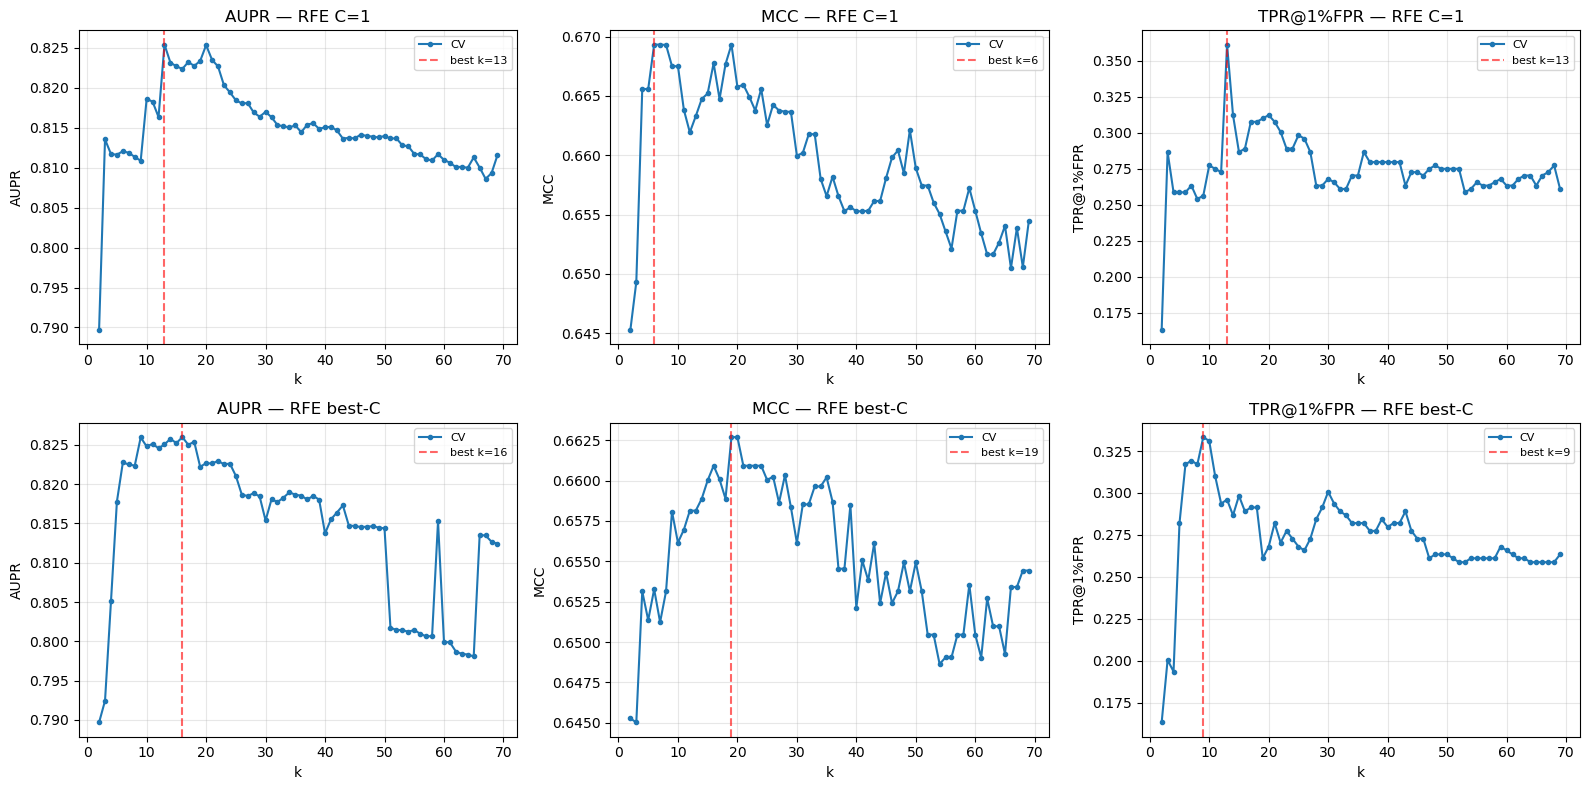

In [8]:
def rfe_cv_arrays(results):
    ks = list(results.keys())
    return (ks,
            [results[k]["aupr"]        for k in ks],   # CV AUPR
            [results[k]["mcc"]         for k in ks],   # CV MCC
            [results[k]["tpr_at_1fpr"] for k in ks])   # CV TPR@1%

ks, cv_aupr_c1,    cv_mcc_c1,    cv_tpr1_c1    = rfe_cv_arrays(rfe_c1_results)
_,  cv_aupr_bestc, cv_mcc_bestc, cv_tpr1_bestc = rfe_cv_arrays(rfe_bestc_results)

best_k_c1_aupr    = ks[np.argmax(cv_aupr_c1)]
best_k_bestc_aupr = ks[np.argmax(cv_aupr_bestc)]
best_k_c1_tpr1    = ks[np.argmax(cv_tpr1_c1)]
best_k_bestc_tpr1 = ks[np.argmax(cv_tpr1_bestc)]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
metrics = ["AUPR", "MCC", "TPR@1%FPR"]
for col, (c1, bc, metric, bk_c1, bk_bc) in enumerate(zip(
        [cv_aupr_c1,    cv_mcc_c1,    cv_tpr1_c1],
        [cv_aupr_bestc, cv_mcc_bestc, cv_tpr1_bestc],
        metrics,
        [best_k_c1_aupr,    ks[np.argmax(cv_mcc_c1)],    best_k_c1_tpr1],
        [best_k_bestc_aupr, ks[np.argmax(cv_mcc_bestc)], best_k_bestc_tpr1])):

    # Top row: C=1
    axes[0, col].plot(ks, c1, "o-", markersize=3, lw=1.5, label="CV")
    axes[0, col].axvline(bk_c1, color="red", ls="--", alpha=0.6, label=f"best k={bk_c1}")
    axes[0, col].set_title(f"{metric} — RFE C=1")
    axes[0, col].set_xlabel("k"); axes[0, col].set_ylabel(metric)
    axes[0, col].legend(fontsize=8); axes[0, col].grid(True, alpha=0.3)

    # Bottom row: best-C
    axes[1, col].plot(ks, bc, "o-", markersize=3, lw=1.5, label="CV")
    axes[1, col].axvline(bk_bc, color="red", ls="--", alpha=0.6, label=f"best k={bk_bc}")
    axes[1, col].set_title(f"{metric} — RFE best-C")
    axes[1, col].set_xlabel("k"); axes[1, col].set_ylabel(metric)
    axes[1, col].legend(fontsize=8); axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fscv_rfe_performance_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()


## Strategy 2 — RFECV

RFECV automates k selection: runs RFE inside its own internal cross-validation
(on the pooled train+val data) and picks the k that maximises CV AUPR. The
selected subset is then re-evaluated with `fit_and_eval_cv`.


=== RFECV with C=1 ===


RFECV rank-C=1: selected k=7 features: ['avg_ipsae', 'min_rc', 'multimer_frac_tm0.0', 'multimer_frac_tm0.1', 'multimer_frac_tm0.3', 'hm_frac_tm0.2', 'structural_consensus_max']

────────────────────────────────────────────────────────────
  RFECV rank-C=1 k=7  (7 features, C=4.28133 [subset-CV], thr=0.615)
              precision    recall  f1-score   support

    negative       0.86      0.94      0.89       820
   homodimer       0.85      0.70      0.77       429

    accuracy                           0.85      1249
   macro avg       0.85      0.82      0.83      1249
weighted avg       0.85      0.85      0.85      1249


=== RFECV with best-C=0.03360 ===
RFECV rank-C=BEST: selected k=20 features: ['avg_ipsae', 'min_iptm', 'avg_iptm', 'avg_ptm', 'min_rc', 'avg_rc', 'multimer_frac_tm0.0', 'multimer_frac_tm0.1', 'multimer_frac_tm0.9', 'hm_frac_tm0.0', 'hm_frac_tm0.1', 'hm_frac_tm0.2', 'hm_frac_tm0.3', 'hm_frac_tm0.7', 'min_contacts_across_predictions', 'best_contact_score_max', 'bu

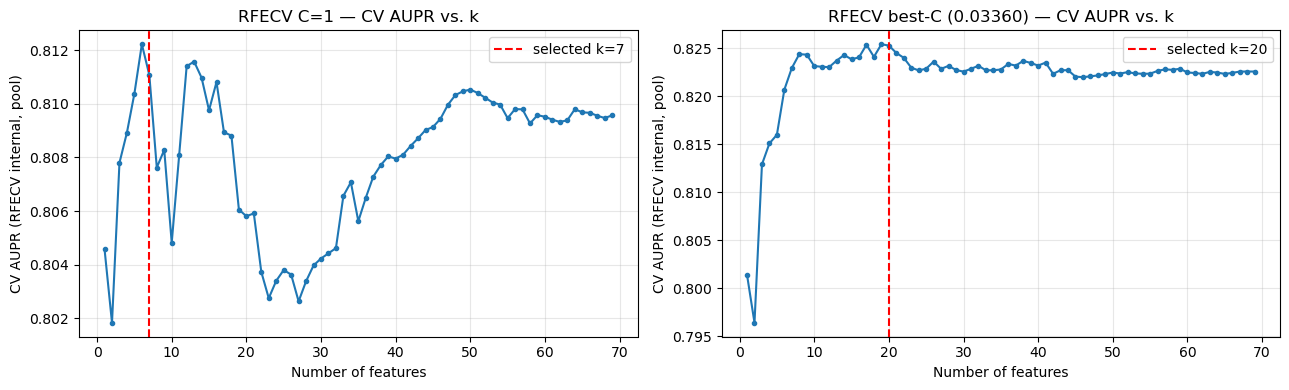

In [9]:
def run_rfecv(ranking_C, label):
    rfecv = RFECV(
        estimator=LogisticRegression(
            C=ranking_C, class_weight="balanced", solver="lbfgs",
            max_iter=2000, random_state=SEED,
        ),
        step=1,
        cv=StratifiedKFold(CV_FOLDS, shuffle=True, random_state=SEED),
        scoring="average_precision",
        min_features_to_select=2,
        n_jobs=-1,
    )
    rfecv.fit(Xtr_all, y_train)
    sel_cols = [ALL_FEATURE_COLS[i] for i, s in enumerate(rfecv.support_) if s]
    print(f"{label}: selected k={rfecv.n_features_} features: {sel_cols}")

    cv_scores = rfecv.cv_results_["mean_test_score"]
    r = fit_and_eval_cv(sel_cols, f"{label} k={rfecv.n_features_}")
    all_results[r["label"]] = r
    return rfecv, r, cv_scores

print("=== RFECV with C=1 ===")
rfecv_c1,    rfecv_c1_result,    cv_scores_c1    = run_rfecv(1.0,    "RFECV rank-C=1")
print()
print(f"=== RFECV with best-C={BEST_C:.5f} ===")
rfecv_bestc, rfecv_bestc_result, cv_scores_bestc = run_rfecv(BEST_C, "RFECV rank-C=BEST")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, cv_scores, rfecv_obj, title in zip(
        axes,
        [cv_scores_c1, cv_scores_bestc],
        [rfecv_c1, rfecv_bestc],
        ["RFECV C=1", f"RFECV best-C ({BEST_C:.5f})"]):
    ax.plot(range(1, len(cv_scores) + 1), cv_scores, marker="o", markersize=3)
    ax.axvline(rfecv_obj.n_features_, color="red", ls="--",
               label=f"selected k={rfecv_obj.n_features_}")
    ax.set_xlabel("Number of features"); ax.set_ylabel("CV AUPR (RFECV internal, pool)")
    ax.set_title(f"{title} — CV AUPR vs. k")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fscv_rfecv_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Strategy 3 — L1 path (SelectFromModel)

L1 regularization drives coefficients to zero; sweeping C gives subsets of
different sizes (fit once on the pooled data). Each unique subset is
cross-validated with `fit_and_eval_cv`.
Best subset selected by CV AUPR and CV TPR@1%FPR.


Evaluated 26 unique L1 subsets


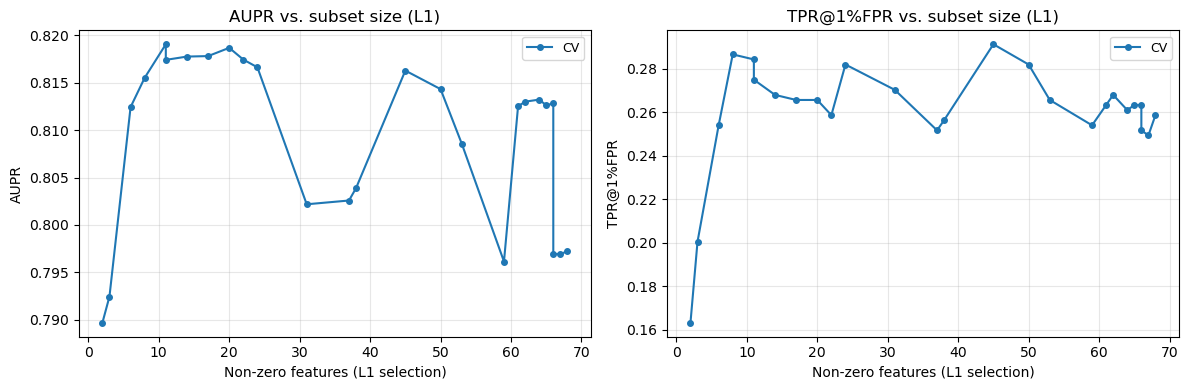


Best L1 subset by CV AUPR: k=11, features=['avg_ipsae', 'avg_ptm', 'min_rc', 'avg_rc', 'hm_frac_tm0.2', 'hm_frac_tm0.3', 'hm_frac_tm0.7', 'min_contacts_across_predictions', 'best_contact_score_max', 'structural_consensus_max', 'foldseek_specificity']
  CV AUPR=0.8190


In [10]:
C_grid = np.logspace(-3, 2, 30)
l1_results = []
seen_subsets = set()

for C in C_grid:
    l1_model = LogisticRegression(
        C=C, penalty="l1", class_weight="balanced",
        solver="liblinear", max_iter=2000, random_state=SEED,
    )
    sfm = SelectFromModel(l1_model, prefit=False)
    sfm.fit(Xtr_all, y_train)
    sel_idx  = sfm.get_support()
    sel_cols = [ALL_FEATURE_COLS[i] for i, s in enumerate(sel_idx) if s]

    if not sel_cols:
        continue
    key = tuple(sorted(sel_cols))
    if key in seen_subsets:
        continue
    seen_subsets.add(key)

    r = fit_and_eval_cv(sel_cols, f"L1 C={C:.4f} k={len(sel_cols)}", verbose=False)
    r["l1_C"] = C
    l1_results.append(r)
    all_results[r["label"]] = r

l1_df = pd.DataFrame([{
    "n_features": r["n_features"],
    "cv_aupr":    r["aupr"],
    "cv_tpr1":    r["tpr_at_1fpr"],
} for r in l1_results]).sort_values("n_features")

print(f"Evaluated {len(l1_results)} unique L1 subsets")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, metric in zip(axes, ["cv_aupr", "cv_tpr1"], ["AUPR", "TPR@1%FPR"]):
    ax.plot(l1_df["n_features"], l1_df[col], "o-", lw=1.5, markersize=4, label="CV")
    ax.set_xlabel("Non-zero features (L1 selection)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs. subset size (L1)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fscv_l1_path.png", dpi=150, bbox_inches="tight")
plt.show()

best_l1 = max(l1_results, key=lambda r: r["aupr"])
print(f"\nBest L1 subset by CV AUPR: k={best_l1['n_features']}, features={best_l1['features']}")
print(f"  CV AUPR={best_l1['aupr']:.4f}")


## Strategy 4 — SelectKBest (univariate F-statistic)

Features ranked independently by F-statistic on the pooled data. Top-k
selected and cross-validated.


Top 15 features by F-statistic:
avg_ipsae                   967.464154
min_rc                      953.203487
min_iptm                    948.590967
iptm_rc_prod                927.272803
avg_rc                      912.404883
avg_iptm                    906.449707
min_ipsae                   903.183274
min_ptm                     796.334458
avg_ptm                     789.551218
max_ipsae                   707.893939
best_contact_score_max      627.213797
max_rc                      621.860211
max_iptm                    606.049245
max_ptm                     605.070169
structural_consensus_min    599.451883


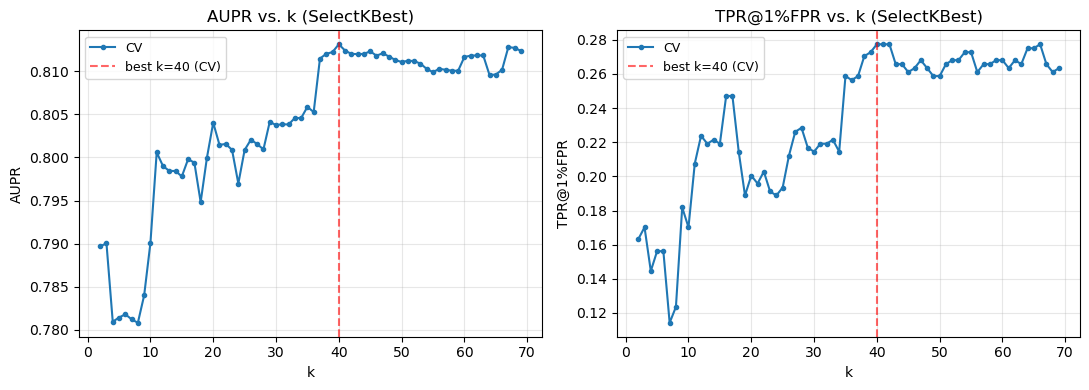


Best k by CV AUPR: k=40  (CV=0.8131)
Features: ['min_ipsae', 'max_ipsae', 'avg_ipsae', 'max_iptm', 'min_iptm', 'avg_iptm', 'max_ptm', 'min_ptm', 'avg_ptm', 'max_rc', 'min_rc', 'avg_rc', 'multimer_frac_tm0.8', 'hm_frac_tm0.0', 'hm_frac_tm0.1', 'hm_frac_tm0.2', 'hm_frac_tm0.3', 'hm_frac_tm0.4', 'hm_frac_tm0.5', 'hm_frac_tm0.6', 'hm_frac_tm0.7', 'hm_frac_tm0.8', 'hm_frac_tm0.9', 'num_contacts_with_max_n_models', 'num_unique_contacts', 'mean_contacts_across_predictions', 'min_contacts_across_predictions', 'best_num_residue_contacts', 'best_if_residues', 'best_plddt_max', 'best_contact_score_max', 'buried_apolar_area_min', 'total_interaction_area_min', 'structural_consensus_mean', 'structural_consensus_min', 'structural_consensus_max', 'iptm_rc_prod', 'ipsae_iptm_diff', 'hm_high_any', 'foldseek_specificity']


In [11]:
skb_results  = {}
skb_features = {}

for k in K_VALUES:
    skb = SelectKBest(f_classif, k=k)
    skb.fit(Xtr_all, y_train)
    sel_cols = [ALL_FEATURE_COLS[i] for i, s in enumerate(skb.get_support()) if s]
    skb_features[k] = sel_cols
    r = fit_and_eval_cv(sel_cols, f"KBest k={k}", verbose=False)
    skb_results[k] = r
    all_results[f"KBest k={k}"] = r

skb_all = SelectKBest(f_classif, k="all")
skb_all.fit(Xtr_all, y_train)
feat_scores = pd.Series(skb_all.scores_, index=ALL_FEATURE_COLS).sort_values(ascending=False)
print("Top 15 features by F-statistic:")
print(feat_scores.head(15).to_string())

ks_skb      = list(skb_results.keys())
cv_aup_skb  = [skb_results[k]["aupr"]        for k in ks_skb]
cv_tpr_skb  = [skb_results[k]["tpr_at_1fpr"] for k in ks_skb]
best_k_skb  = ks_skb[np.argmax(cv_aup_skb)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, vals, metric, best_k in zip(
        axes,
        [cv_aup_skb, cv_tpr_skb],
        ["AUPR",     "TPR@1%FPR"],
        [best_k_skb, ks_skb[np.argmax(cv_tpr_skb)]]):
    ax.plot(ks_skb, vals, marker="o", markersize=3, lw=1.5, label="CV")
    ax.axvline(best_k, color="red", ls="--", alpha=0.6, label=f"best k={best_k} (CV)")
    ax.set_xlabel("k"); ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs. k (SelectKBest)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fscv_kbest_performance_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBest k by CV AUPR: k={best_k_skb}  (CV={max(cv_aup_skb):.4f})")
print(f"Features: {skb_features[best_k_skb]}")


## Strategy 5 — Forward Sequential Selection

Greedily adds the feature that improves CV AUPR most at each step (ranking
step uses its own internal 3-fold CV, on the pooled train+val data — this was
already cross-validated in `feature_selection_validation.ipynb`, just over
more rows here). Each resulting k-subset is then cross-validated with
`fit_and_eval_cv`.


=== Forward SFS with C=1 (ranking estimator) ===
  [FwdSFS rank-C=1] Step  1/69: added 'avg_rc'  CV AUPR=0.7978
  [FwdSFS rank-C=1] Step  2/69: added 'hm_frac_tm0.2'  CV AUPR=0.8186
  [FwdSFS rank-C=1] Step  3/69: added 'foldseek_specificity'  CV AUPR=0.8221
  [FwdSFS rank-C=1] Step  4/69: added 'min_ipsae'  CV AUPR=0.8266
  [FwdSFS rank-C=1] Step  5/69: added 'multimer_frac_tm0.9'  CV AUPR=0.8288
  [FwdSFS rank-C=1] Step  6/69: added 'hm_high_any'  CV AUPR=0.8305
  [FwdSFS rank-C=1] Step  7/69: added 'num_unique_contacts'  CV AUPR=0.8318
  [FwdSFS rank-C=1] Step  8/69: added 'multimer_frac_tm0.2'  CV AUPR=0.8327
  [FwdSFS rank-C=1] Step  9/69: added 'multimer_frac_tm0.3'  CV AUPR=0.8337
  [FwdSFS rank-C=1] Step 10/69: added 'fraction_buried_apolar_area_min'  CV AUPR=0.8348
  [FwdSFS rank-C=1] Step 11/69: added 'highest_tm_multimers'  CV AUPR=0.8352
  [FwdSFS rank-C=1] Step 12/69: added 'multimer_frac_tm0.4'  CV AUPR=0.8353
  [FwdSFS rank-C=1] Step 13/69: added 'ipsae_iptm_diff'  CV AU

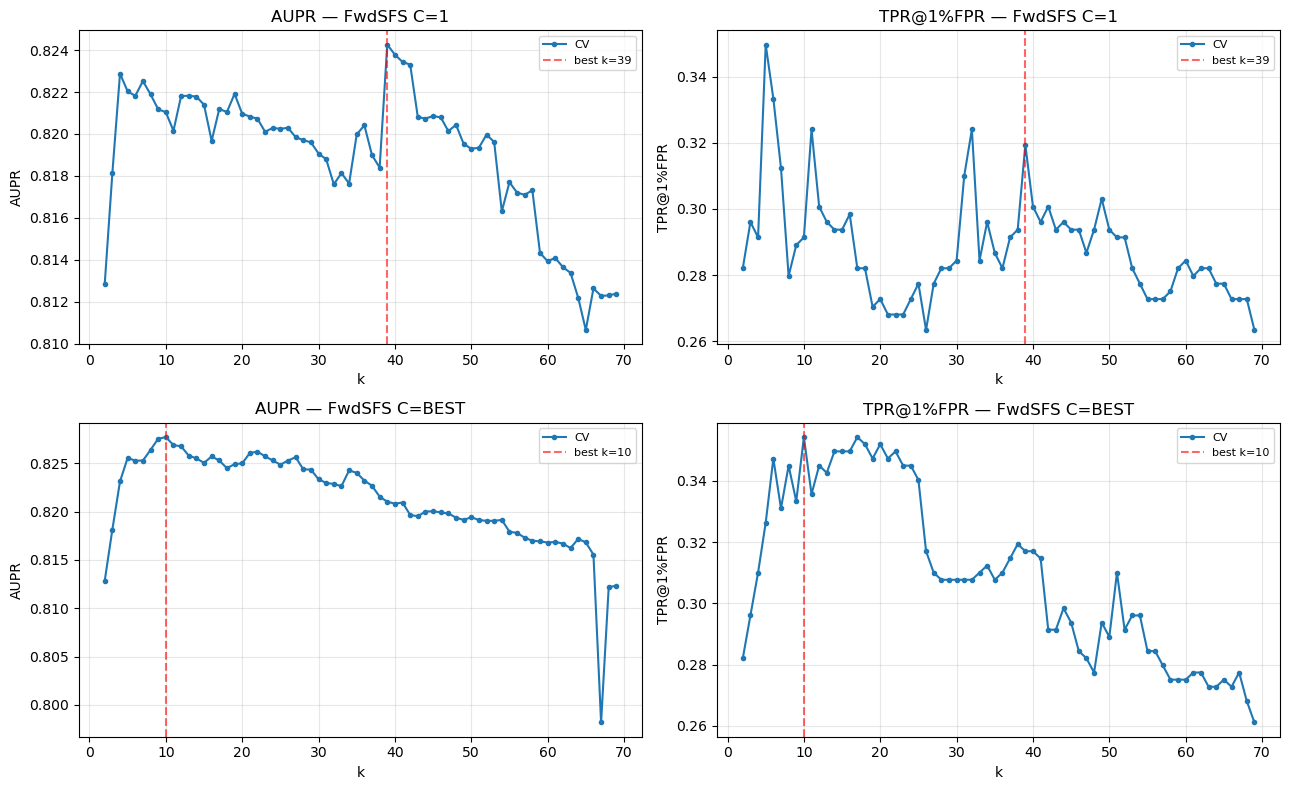

In [12]:
def run_forward_selection(ranking_C, label_prefix, cv_folds=3):
    # Build full forward selection path, then cross-validate each k subset.
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(C=ranking_C, class_weight="balanced",
                                      solver="lbfgs", max_iter=2000, random_state=SEED)),
    ])
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    remaining = list(range(Xtr_all.shape[1]))
    selected  = []
    n_steps   = min(max(K_VALUES), Xtr_all.shape[1])  # can't select more features than we have

    for step in range(n_steps):
        best_score, best_feat = -np.inf, None
        for feat in remaining:
            X_curr = Xtr_all[:, selected + [feat]]
            score  = cross_val_score(pipe, X_curr, y_train, cv=cv,
                                     scoring="average_precision", n_jobs=-1).mean()
            if score > best_score:
                best_score, best_feat = score, feat
        selected.append(best_feat)
        remaining.remove(best_feat)
        print(f"  [{label_prefix}] Step {step+1:>2}/{n_steps}: "
              f"added '{ALL_FEATURE_COLS[best_feat]}'  CV AUPR={best_score:.4f}", flush=True)

    results  = {}
    features = {}
    for k in [k for k in K_VALUES if k <= len(selected)]:
        sel_cols    = [ALL_FEATURE_COLS[i] for i in selected[:k]]
        features[k] = sel_cols
        r = fit_and_eval_cv(sel_cols, f"{label_prefix} k={k}", verbose=False)
        results[k]  = r
        all_results[r["label"]] = r
    return results, features


print("=== Forward SFS with C=1 (ranking estimator) ===")
fwd_c1_results,    fwd_c1_features    = run_forward_selection(1.0,    "FwdSFS rank-C=1")
print()
print(f"=== Forward SFS with best-C={BEST_C:.5f} (ranking estimator) ===")
fwd_bestc_results, fwd_bestc_features = run_forward_selection(BEST_C, "FwdSFS rank-C=BEST")

ks_fwd = list(fwd_c1_results.keys())
best_k_fwd_c1    = ks_fwd[np.argmax([fwd_c1_results[k]["aupr"]    for k in ks_fwd])]
best_k_fwd_bestc = ks_fwd[np.argmax([fwd_bestc_results[k]["aupr"] for k in ks_fwd])]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (results, ranking_c, bk) in enumerate([
        (fwd_c1_results,    "C=1",    best_k_fwd_c1),
        (fwd_bestc_results, "C=BEST", best_k_fwd_bestc)]):
    for col, (v_col, metric) in enumerate([
            ("aupr",        "AUPR"),
            ("tpr_at_1fpr", "TPR@1%FPR")]):
        ax = axes[row, col]
        ax.plot(ks_fwd, [results[k][v_col] for k in ks_fwd], "o-", lw=1.5, markersize=3, label="CV")
        ax.axvline(bk, color="red", ls="--", alpha=0.6, label=f"best k={bk}")
        ax.set_title(f"{metric} — FwdSFS {ranking_c}")
        ax.set_xlabel("k"); ax.set_ylabel(metric)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fscv_fwd_performance_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()


## Strategy 6 — Tree-based feature importance (ExtraTreesClassifier)

Fits once on the pooled train+val data to rank features. Top-k
cross-validated.


Top 15 features by ExtraTrees importance:
avg_ipsae                   0.053835
avg_rc                      0.041905
min_iptm                    0.040472
avg_iptm                    0.038797
min_rc                      0.036552
min_ipsae                   0.035146
iptm_rc_prod                0.034846
max_ipsae                   0.033846
max_rc                      0.033142
min_ptm                     0.027884
max_iptm                    0.024011
avg_ptm                     0.022346
structural_consensus_min    0.017812
best_contact_score_max      0.016526
max_ptm                     0.016330


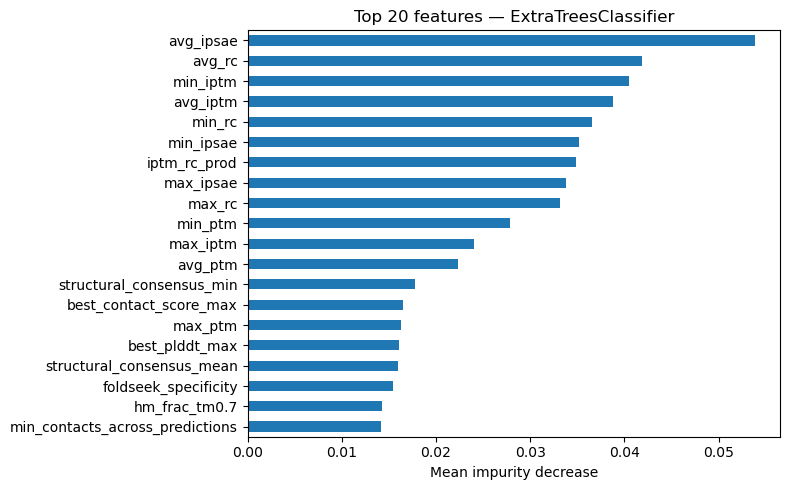

Tree-based sweep complete.
Best k by CV AUPR: k=26  (CV=0.8169)
Features: ['avg_ipsae', 'avg_rc', 'min_iptm', 'avg_iptm', 'min_rc', 'min_ipsae', 'iptm_rc_prod', 'max_ipsae', 'max_rc', 'min_ptm', 'max_iptm', 'avg_ptm', 'structural_consensus_min', 'best_contact_score_max', 'max_ptm', 'best_plddt_max', 'structural_consensus_mean', 'foldseek_specificity', 'hm_frac_tm0.7', 'min_contacts_across_predictions', 'structural_consensus_max', 'ipsae_iptm_diff', 'hm_frac_tm0.4', 'hm_frac_tm0.5', 'hm_frac_tm0.2', 'hm_low_high_gap']


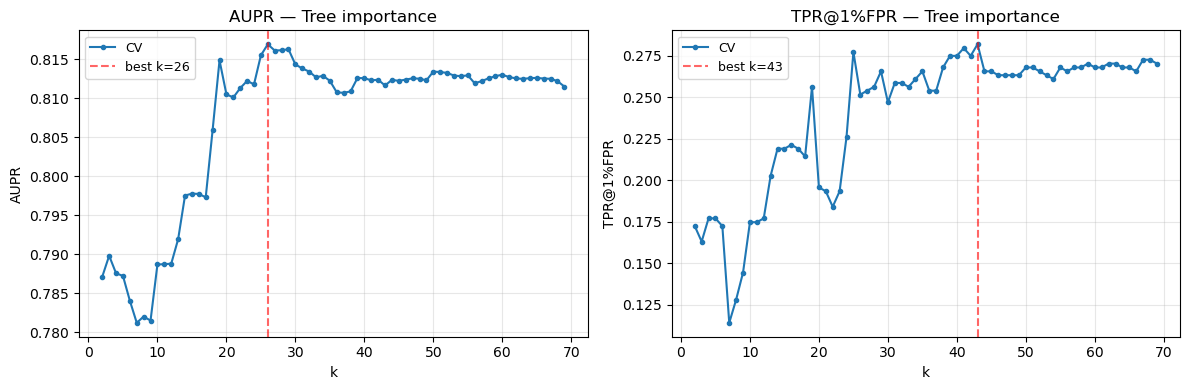

In [13]:
etc = ExtraTreesClassifier(
    n_estimators=300, class_weight="balanced",
    random_state=SEED, n_jobs=-1,
)
etc.fit(Xtr_all, y_train)

tree_importances = pd.Series(etc.feature_importances_, index=ALL_FEATURE_COLS).sort_values(ascending=False)
print("Top 15 features by ExtraTrees importance:")
print(tree_importances.head(15).to_string())

plt.figure(figsize=(8, 5))
tree_importances.head(20).sort_values().plot(kind="barh")
plt.xlabel("Mean impurity decrease"); plt.title("Top 20 features — ExtraTreesClassifier")
plt.tight_layout()
plt.savefig("fscv_tree_importances.png", dpi=150, bbox_inches="tight")
plt.show()

tree_results  = {}
tree_features = {}

for k in K_VALUES:
    sel_cols = tree_importances.index[:k].tolist()
    tree_features[k] = sel_cols
    r = fit_and_eval_cv(sel_cols, f"Tree k={k}", verbose=False)
    tree_results[k]  = r
    all_results[r["label"]] = r

print("Tree-based sweep complete.")
ks_tree     = list(tree_results.keys())
cv_aup_tr   = [tree_results[k]["aupr"] for k in ks_tree]
best_k_tree = ks_tree[np.argmax(cv_aup_tr)]
print(f"Best k by CV AUPR: k={best_k_tree}  (CV={max(cv_aup_tr):.4f})")
print(f"Features: {tree_features[best_k_tree]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, metric, bk in zip(
        axes,
        ["aupr",      "tpr_at_1fpr"],
        ["AUPR",      "TPR@1%FPR"],
        [best_k_tree, ks_tree[np.argmax([tree_results[k]["tpr_at_1fpr"] for k in ks_tree])]]):
    ax.plot(ks_tree, [tree_results[k][col] for k in ks_tree], "o-", markersize=3, lw=1.5, label="CV")
    ax.axvline(bk, color="red", ls="--", alpha=0.6, label=f"best k={bk}")
    ax.set_xlabel("k"); ax.set_ylabel(metric)
    ax.set_title(f"{metric} — Tree importance")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fscv_tree_performance_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary — every evaluated subset × three evaluation-C modes

Feature selection uses **CV (out-of-fold)** metrics over the pooled train+val
set throughout. Every k from every strategy above is evaluated with three
final-C modes.

| Eval C mode | What it means |
|---|---|
| `C=1.0` | Fixed C=1 (sklearn default) |
| `C=BEST` | Fixed C found by LRCV on all features (pooled) |
| `C=subset-CV` | `LogisticRegressionCV` re-run on the selected feature subset (pooled) |

`*` marks the column-best value.


In [14]:
# ── Collect ALL evaluated subsets across every method (exhaustive comparison) ──
strategies = []
for name, (res, feats) in {
    "RFE  rank-C=1":      (rfe_c1_results,    rfe_c1_features),
    "RFE  rank-C=BEST":   (rfe_bestc_results, rfe_bestc_features),
    "FwdSFS rank-C=1":    (fwd_c1_results,    fwd_c1_features),
    "FwdSFS rank-C=BEST": (fwd_bestc_results, fwd_bestc_features),
    "Tree":               (tree_results,      tree_features),
    "KBest":              (skb_results,       skb_features),
}.items():
    for k in res:
        strategies.append((f"{name} k={k}", "all-k", feats[k]))

# L1-path: every unique subset size found along the regularization path
for r in l1_results:
    strategies.append((f"L1-path k={r['n_features']}", "all-k", r["features"]))

strategies += [(f"RFECV rank-C=1    k={rfecv_c1.n_features_}",    "CV auto", rfecv_c1_result["features"])]
strategies += [(f"RFECV rank-C=BEST k={rfecv_bestc.n_features_}", "CV auto", rfecv_bestc_result["features"])]

print(f"Strategy x criterion pairs: {len(strategies)}")
for s, c, f in strategies:
    print(f"  {s:<45}  criterion={c:<22}  k={len(f)}")


# ── Evaluate each subset x 3 eval-C modes ─────────────────────────────────────
eval_modes = [
    ("C=1.0",       1.0),
    ("C=BEST",      BEST_C),
    ("C=subset-CV", None),
]

print(f"\nEvaluating {len(strategies)} pairs x {len(eval_modes)} eval-C modes ...\n")
all_summary_results = {}

for strat_name, criterion, feats in strategies:
    for mode_name, c_val in eval_modes:
        r = fit_and_eval_cv(feats, f"{strat_name}|{criterion}|{mode_name}",
                            verbose=False, eval_C=c_val)
        if r:
            all_summary_results[(strat_name, criterion, mode_name)] = r
        print(f"  {strat_name:<45} {criterion:<22} {mode_name:<14}  "
              f"CV AUPR={r['aupr']:.4f}  CV TPR@1%={r['tpr_at_1fpr']:.4f}", flush=True)


# ── Build comparison table ─────────────────────────────────────────────────────
metric_cols = ["CV AUPR", "CV MCC", "CV ROC-AUC", "CV F1", "CV TPR@5%FPR", "CV TPR@1%FPR"]

rows = []
for (strat, crit, mode), r in all_summary_results.items():
    rows.append({
        "Strategy": strat, "Criterion": crit, "Eval C": mode,
        "N feat": r["n_features"], "Fit C": r["best_C"],
        "CV AUPR":      r["aupr"],
        "CV MCC":       r["mcc"],
        "CV ROC-AUC":   r["roc_auc"],
        "CV F1":        r["f1"],
        "CV TPR@5%FPR": r["tpr_at_5fpr"],
        "CV TPR@1%FPR": r["tpr_at_1fpr"],
    })

summary_df = pd.DataFrame(rows)
best_vals = {col: summary_df[col].max() for col in metric_cols}

def fmt_metric(v, col):
    return f"{v:.4f}*" if v == best_vals[col] else f"{v:.4f}"

display_rows = []
for _, row in summary_df.iterrows():
    display_rows.append({
        "Strategy": row["Strategy"], "Criterion": row["Criterion"], "Eval C": row["Eval C"],
        "N feat": int(row["N feat"]), "Fit C": f"{row['Fit C']:.5f}",
        **{col: fmt_metric(row[col], col) for col in metric_cols},
    })

display_df = pd.DataFrame(display_rows).set_index(["Strategy", "Criterion", "Eval C"])

print(f"\nPooled train+val — every evaluated subset x 3 eval-C modes (exhaustive)")
print(f"(BEST_C={BEST_C:.6f}  |  CV_FOLDS={CV_FOLDS}  |  * = column best)\n")
with pd.option_context("display.max_rows", 2000, "display.max_colwidth", 55):
    display(display_df)

# ── Top 5 quick-views ──────────────────────────────────────────────────────────
cols_short = ["Strategy", "Criterion", "Eval C", "N feat", "CV AUPR", "CV MCC", "CV TPR@1%FPR"]

print("\nTop 5 by CV AUPR:")
print(summary_df[cols_short].sort_values("CV AUPR", ascending=False).head(5).to_string(index=False))

print("\nTop 5 by CV TPR@1%FPR:")
print(summary_df[cols_short].sort_values("CV TPR@1%FPR", ascending=False).head(5).to_string(index=False))

# ── Best metrics across all strategies and eval-C modes ───────────────────────
for metric, col in [("CV TPR@1%FPR", "CV TPR@1%FPR"), ("CV AUPR", "CV AUPR")]:
    best_val = summary_df[col].max()
    tied = summary_df[summary_df[col] == best_val]
    print(f"\n{'─'*60}")
    print(f"Best {metric}: {best_val:.4f}  ({len(tied)} tied entries)")
    for _, row in tied.iterrows():
        print(f"  {row['Strategy']}  |  criterion={row['Criterion']}  |  {row['Eval C']}  "
              f"  k={int(row['N feat'])}")
        feats = all_summary_results[(row['Strategy'], row['Criterion'], row['Eval C'])]["features"]
        print(f"  Features: {feats}")


# ── Save this pass's sweep results for the final cell to load later ──────────
# Run this notebook TWICE (EXCLUDE_HOMOLOGY_FEATURES False, then True, set in
# the config cell, with a Restart Kernel + Run All each time) so both files
# below exist for the final test-set cell to load and compare.
import pickle

SWEEP_CACHE_PATH = f"cv_sweep_{'without' if EXCLUDE_HOMOLOGY_FEATURES else 'with'}_homology.pkl"
with open(SWEEP_CACHE_PATH, "wb") as fh:
    pickle.dump({
        "exclude_homology_features": EXCLUDE_HOMOLOGY_FEATURES,
        "all_feature_cols":          ALL_FEATURE_COLS,
        "best_c":                    BEST_C,
        "all_summary_results":       all_summary_results,
    }, fh)
print(f"\nSaved sweep results to {SWEEP_CACHE_PATH}  ({len(all_summary_results)} rows)")


Strategy x criterion pairs: 436
  RFE  rank-C=1 k=2                              criterion=all-k                   k=2
  RFE  rank-C=1 k=3                              criterion=all-k                   k=3
  RFE  rank-C=1 k=4                              criterion=all-k                   k=4
  RFE  rank-C=1 k=5                              criterion=all-k                   k=5
  RFE  rank-C=1 k=6                              criterion=all-k                   k=6
  RFE  rank-C=1 k=7                              criterion=all-k                   k=7
  RFE  rank-C=1 k=8                              criterion=all-k                   k=8
  RFE  rank-C=1 k=9                              criterion=all-k                   k=9
  RFE  rank-C=1 k=10                             criterion=all-k                   k=10
  RFE  rank-C=1 k=11                             criterion=all-k                   k=11
  RFE  rank-C=1 k=12                             criterion=all-k                   k=12
  RFE  r

  RFE  rank-C=1 k=3                             all-k                  C=subset-CV     CV AUPR=0.8135  CV TPR@1%=0.2867
  RFE  rank-C=1 k=4                             all-k                  C=1.0           CV AUPR=0.8117  CV TPR@1%=0.2634
  RFE  rank-C=1 k=4                             all-k                  C=BEST          CV AUPR=0.8114  CV TPR@1%=0.2517
  RFE  rank-C=1 k=4                             all-k                  C=subset-CV     CV AUPR=0.8117  CV TPR@1%=0.2587
  RFE  rank-C=1 k=5                             all-k                  C=1.0           CV AUPR=0.8117  CV TPR@1%=0.2634
  RFE  rank-C=1 k=5                             all-k                  C=BEST          CV AUPR=0.8115  CV TPR@1%=0.2564
  RFE  rank-C=1 k=5                             all-k                  C=subset-CV     CV AUPR=0.8116  CV TPR@1%=0.2587
  RFE  rank-C=1 k=6                             all-k                  C=1.0           CV AUPR=0.8122  CV TPR@1%=0.2611
  RFE  rank-C=1 k=6                     

N feat      Fit C  CV AUPR  \
Strategy                Criterion Eval C                                    
RFE  rank-C=1 k=2       all-k     C=1.0             2    1.00000   0.7889   
                                  C=BEST            2    0.03360   0.7908   
                                  C=subset-CV       2    0.08859   0.7897   
RFE  rank-C=1 k=3       all-k     C=1.0             3    1.00000   0.8092   
                                  C=BEST            3    0.03360   0.8108   
                                  C=subset-CV       3    0.00483   0.8135   
RFE  rank-C=1 k=4       all-k     C=1.0             4    1.00000   0.8117   
                                  C=BEST            4    0.03360   0.8114   
                                  C=subset-CV       4    0.61585   0.8117   
RFE  rank-C=1 k=5       all-k     C=1.0             5    1.00000   0.8117   
                                  C=BEST            5    0.03360   0.8115   
                                  C=subset-CV       5    0.61585   0.8116   
RFE  rank-C=1 k=6       all-k     C=1.0             6    1.00000   0.8122   
                                  C=BEST            6    0.03360   0.8117   
                                  C=subset-CV       6   78.47600   0.8121   
RFE  rank-C=1 k=7       all-k     C=1.0             7    1.00000   0.8119   
                                  C=BEST            7    0.03360   0.8117   
                                  C=subset-CV       7    4.28133   0.8119   
RFE  rank-C=1 k=8       all-k     C=1.0             8    1.00000   0.8112   
                                  C=BEST            8    0.03360   0.8106   
                                  C=subset-CV       8    0.61585   0.8114   
RFE  rank-C=1 k=9       all-k     C=1.0             9    1.00000   0.8110   
                                  C=BEST            9    0.03360   0.8099   
                                  C=subset-CV       9   11.28838   0.8109   
RFE  rank-C=1 k=10      all-k     C=1.0            10    1.00000   0.8182   
                                  C=BEST           10    0.03360   0.8176   
                                  C=subset-CV      10    0.23357   0.8186   
RFE  rank-C=1 k=11      all-k     C=1.0            11    1.00000   0.8181   
                                  C=BEST           11    0.03360   0.8172   
                                  C=subset-CV      11    0.61585   0.8183   
RFE  rank-C=1 k=12      all-k     C=1.0            12    1.00000   0.8179   
                                  C=BEST           12    0.03360   0.8159   
                                  C=subset-CV      12   29.76351   0.8163   
RFE  rank-C=1 k=13      all-k     C=1.0            13    1.00000   0.8255   
                                  C=BEST           13    0.03360   0.8240   
                                  C=subset-CV      13    0.61585   0.8254   
RFE  rank-C=1 k=14      all-k     C=1.0            14    1.00000   0.8224   
                                  C=BEST           14    0.03360   0.8223   
                                  C=subset-CV      14    0.08859   0.8232   
RFE  rank-C=1 k=15      all-k     C=1.0            15    1.00000   0.8189   
                                  C=BEST           15    0.03360   0.8220   
                                  C=subset-CV      15    0.08859   0.8227   
RFE  rank-C=1 k=16      all-k     C=1.0            16    1.00000   0.8189   
                                  C=BEST           16    0.03360   0.8218   
                                  C=subset-CV      16    0.08859   0.8224   
RFE  rank-C=1 k=17      all-k     C=1.0            17    1.00000   0.8193   
                                  C=BEST           17    0.03360   0.8225   
                                  C=subset-CV      17    0.08859   0.8232   
RFE  rank-C=1 k=18      all-k     C=1.0            18    1.00000   0.8220   
                                  C=BEST           18    0.03360   0.8215   
                                  C=subset-


Top 5 by CV AUPR:
               Strategy Criterion      Eval C  N feat  CV AUPR   CV MCC  CV TPR@1%FPR
FwdSFS rank-C=BEST k=10     all-k      C=BEST      10 0.827697 0.667755      0.354312
FwdSFS rank-C=BEST k=10     all-k C=subset-CV      10 0.827697 0.667755      0.354312
 FwdSFS rank-C=BEST k=9     all-k      C=BEST       9 0.827531 0.665943      0.333333
 FwdSFS rank-C=BEST k=9     all-k C=subset-CV       9 0.827531 0.665943      0.333333
FwdSFS rank-C=BEST k=11     all-k C=subset-CV      11 0.826875 0.660921      0.335664

Top 5 by CV TPR@1%FPR:
               Strategy Criterion      Eval C  N feat  CV AUPR   CV MCC  CV TPR@1%FPR
     RFE  rank-C=1 k=13     all-k C=subset-CV      13 0.825417 0.663299      0.361305
 FwdSFS rank-C=BEST k=6     all-k       C=1.0       6 0.823046 0.652640      0.356643
FwdSFS rank-C=BEST k=17     all-k C=subset-CV      17 0.825279 0.664239      0.354312
FwdSFS rank-C=BEST k=10     all-k C=subset-CV      10 0.827697 0.667755      0.354312
     RFE  r

In [15]:
# ── Best metrics — ties broken / sorted by the other metric ───────────────────
for primary_col, secondary_col in [("CV TPR@1%FPR", "CV AUPR"),
                                    ("CV AUPR",      "CV TPR@1%FPR")]:
    best_val    = summary_df[primary_col].max()
    tied        = summary_df[summary_df[primary_col] == best_val]
    tied_sorted = tied.sort_values(secondary_col, ascending=False)
    print(f"\n{'─'*60}")
    print(f"Best {primary_col}: {best_val:.4f}  "
          f"({len(tied)} tied {'entry' if len(tied) == 1 else 'entries'}, "
          f"sorted by {secondary_col})")
    for _, row in tied_sorted.iterrows():
        feats = all_summary_results[(row["Strategy"], row["Criterion"], row["Eval C"])]["features"]
        print(f"  {row['Strategy']}  |  criterion={row['Criterion']}  |  {row['Eval C']}  "
              f"  k={int(row['N feat'])}")
        print(f"    {primary_col}: {row[primary_col]:.4f}   {secondary_col}: {row[secondary_col]:.4f}")
        print(f"    Features: {feats}")



────────────────────────────────────────────────────────────
Best CV TPR@1%FPR: 0.3613  (1 tied entry, sorted by CV AUPR)
  RFE  rank-C=1 k=13  |  criterion=all-k  |  C=subset-CV    k=13
    CV TPR@1%FPR: 0.3613   CV AUPR: 0.8254
    Features: ['avg_ipsae', 'min_iptm', 'min_rc', 'multimer_frac_tm0.0', 'multimer_frac_tm0.1', 'multimer_frac_tm0.3', 'hm_frac_tm0.2', 'best_contact_score_max', 'structural_consensus_mean', 'structural_consensus_min', 'structural_consensus_max', 'iptm_rc_prod', 'foldseek_specificity']

────────────────────────────────────────────────────────────
Best CV AUPR: 0.8277  (2 tied entries, sorted by CV TPR@1%FPR)
  FwdSFS rank-C=BEST k=10  |  criterion=all-k  |  C=BEST    k=10
    CV AUPR: 0.8277   CV TPR@1%FPR: 0.3543
    Features: ['avg_rc', 'hm_frac_tm0.2', 'foldseek_specificity', 'best_contact_score_max', 'multimer_frac_tm0.0', 'min_ipsae', 'multimer_frac_tm0.9', 'hm_frac_tm0.3', 'multimer_frac_tm0.5', 'fraction_buried_apolar_area_min']
  FwdSFS rank-C=BEST k=

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL TEST-SET EVALUATION — manuscript table
# This is the only place in this notebook that uses the test set.
# Isolated here deliberately so test-set leakage cannot affect feature selection.
# ══════════════════════════════════════════════════════════════════════════════

threshold_method = "1_FPR"   # "1_FPR" | "best_mcc" | "best_f1"

# ── Load test labels (df and _split already in memory from load cell) ─────────
test_mask = df["ID"].isin(set(_split["test"])).values
y_test    = y[test_mask]
print(f"Test set: {test_mask.sum()} samples  ({y_test.sum()} positives)")

# ── Chosen feature sets from CV-based selection ────────────────────────────────
# This notebook is meant to be run TWICE (EXCLUDE_HOMOLOGY_FEATURES False, then
# True, in the config cell -- Restart Kernel + Run All each time). This final
# cell loads BOTH saved sweeps from disk below and automatically pulls the top
# candidates from each, so you don't need to hand-copy a feature list. The
# lines below are optional manual pins -- kept only so you can compare a
# specific historical pick against whatever the sweep actually found;
# uncomment either to include it alongside the automatic picks.
# WITH_FOLDSEEK_FEATURES = ['avg_ipsae', 'min_iptm', 'multimer_frac_tm0.0', 'hm_frac_tm0.2', 'hm_frac_tm0.8', 'min_contacts_across_predictions', 'best_contact_score_max']
# WITH_FOLDSEEK_FEATURES = ['avg_rc', 'hm_frac_tm0.2', 'multimer_frac_tm0.0', 'best_contact_score_max', 'hm_frac_tm0.8', 'min_ipsae', 'fraction_buried_apolar_area_min', 'multimer_frac_tm0.1', 'multimer_frac_tm0.9', 'hm_frac_tm0.7', 'hm_frac_tm0.3', 'multimer_frac_tm0.7', 'structural_consensus_max', 'multimer_frac_tm0.6']

# NOFS_FEATURES = ['min_rc', 'best_contact_score_max', 'fraction_buried_apolar_area_min', 'structural_consensus_max', 'buried_apolar_area_min', 'fraction_buried_polar_area_min', 'best_plddt_max', 'fraction_buried_apolar_area_max', 'buried_polar_area_max', 'structural_consensus_mean', 'fraction_buried_polar_area_max', 'avg_ipsae', 'fraction_buried_apolar_area_mean', 'fraction_buried_polar_area_mean', 'max_ptm', 'min_iptm', 'total_interaction_area_max', 'best_pae_min', 'max_rc', 'max_ipsae', 'max_iptm', 'min_ptm', 'avg_ptm']


# ── Load both sweep passes from disk ──────────────────────────────────────────
import pickle
from pathlib import Path

def _load_sweep(path):
    if not Path(path).exists():
        return None
    with open(path, "rb") as fh:
        return pickle.load(fh)

sweep_with    = _load_sweep("cv_sweep_with_homology.pkl")
sweep_without = _load_sweep("cv_sweep_without_homology.pkl")

for _name, _sweep in [("with-homology", sweep_with), ("without-homology", sweep_without)]:
    if _sweep is None:
        print(f"WARNING: {_name} sweep cache not found on disk -- set "
              f"EXCLUDE_HOMOLOGY_FEATURES accordingly in the config cell, do "
              f"Restart Kernel + Run All, then re-run this cell.")
    else:
        print(f"Loaded {_name} sweep: {len(_sweep['all_summary_results'])} evaluated rows, "
              f"{len(_sweep['all_feature_cols'])} candidate features, BEST_C={_sweep['best_c']:.6g}")

def _tag_results(sweep, tag):
    if sweep is None:
        return {}
    return {(f"[{tag}] {strat}", crit, mode): r
            for (strat, crit, mode), r in sweep["all_summary_results"].items()}

# merged, uniquely-keyed lookup table used by best_c_for_features below. Note:
# its "not found -- evaluate fresh" fallback path uses whichever BEST_C/
# ALL_FEATURE_COLS/CV_FOLDS are CURRENTLY bound in this kernel (i.e. from
# whichever pass you ran last) -- this only matters for feature lists that
# were never evaluated in either saved sweep.
all_summary_results = {**_tag_results(sweep_with, "with-homology"),
                       **_tag_results(sweep_without, "without-homology")}


# ── fit_and_eval_test: fit on the POOLED train+val set, evaluate on TEST ──────
def fit_and_eval_test(features, label, eval_C=None):
    # Fit on the pooled train+val set, predict on TEST. ONLY for the final
    # manuscript table. Since feature selection above is already CV-based over
    # the full pool (no held-out val is needed to protect), the final model is
    # trained on ALL non-test rows -- unlike feature_selection_validation.ipynb,
    # which retrains on train only.
    X_tr = df[features].values[trainval_mask].astype(float)
    X_te = df[features].values[test_mask].astype(float)

    scaler = StandardScaler()
    Xtr    = scaler.fit_transform(X_tr)
    Xte    = scaler.transform(X_te)

    if eval_C is None:
        lrcv = LogisticRegressionCV(
            Cs=np.logspace(-4, 4, 20), cv=CV_FOLDS, class_weight="balanced",
            solver="lbfgs", max_iter=2000, scoring="average_precision",
            random_state=SEED, n_jobs=-1,
        )
        lrcv.fit(Xtr, y_train)
        best_C = float(lrcv.C_[0])
    else:
        best_C = float(eval_C)

    model = LogisticRegression(C=best_C, class_weight="balanced",
                               solver="lbfgs", max_iter=2000, random_state=SEED)
    prob_oof = cross_val_predict(model, Xtr, y_train, cv=CV_FOLDS,
                                 method="predict_proba")[:, 1]
    thresholds = np.linspace(0.01, 0.99, 500)
    best_t = float(thresholds[np.argmax(
        [matthews_corrcoef(y_train, (prob_oof >= t).astype(int)) for t in thresholds]
    )])

    model.fit(Xtr, y_train)
    prob_test = model.predict_proba(Xte)[:, 1]

    return {
        "label":    label,
        "features": features,
        "best_C":   best_C,
        "threshold": best_t,
        "prob_test": prob_test,
        "prob_oof":  prob_oof,
    }


def best_c_for_features(features, label=None, primary_metric="aupr", verbose=True):
    # Find the C that performs best on CV for this exact feature set,
    # choosing among C=1.0, C=BEST, and C=subset-CV -- the same three modes
    # used in the exhaustive sweep above.
    #
    # If this exact feature set was already evaluated there, the cached
    # all_summary_results entries are reused (no refit). Otherwise -- e.g. a
    # hand-picked/experimental feature set -- it is evaluated now under all
    # three modes via fit_and_eval_cv (train+val pool only, test set
    # untouched), the new results are cached into all_summary_results for
    # reuse, and the C with the best `primary_metric` on CV is returned.
    feat_set = set(features)

    def _matches():
        return [
            (key, r) for key, r in all_summary_results.items()
            if set(r["features"]) == feat_set
        ]

    matches = _matches()
    if not matches:
        label = label or "manual:" + "+".join(sorted(feat_set))[:60]
        if verbose:
            print(f"  [best_c_for_features] '{label}' not found in the sweep -- "
                  f"evaluating under all 3 eval-C modes now (train+val pool only)")
        for mode_name, c_val in [("C=1.0", 1.0), ("C=BEST", BEST_C), ("C=subset-CV", None)]:
            r = fit_and_eval_cv(features, f"{label}|manual|{mode_name}", verbose=False, eval_C=c_val)
            if r:
                all_summary_results[(label, "manual", mode_name)] = r
        matches = _matches()

    assert matches, f"could not evaluate feature set (missing columns?): {sorted(feat_set)}"
    key, best_r = max(matches, key=lambda kv: kv[1][primary_metric])
    if verbose:
        print(f"  [best_c_for_features] matched {key} -- "
              f"C={best_r['best_C']:.5g}  CV {primary_metric}={best_r[primary_metric]:.4f}")
    return best_r["best_C"]


def recompute_metrics_test(r, method):
    # Compute metrics on the test set at the chosen threshold.
    prob_oof  = r["prob_oof"]
    prob_test = r["prob_test"]

    if method == "1_FPR":
        fpr_arr, _, thrs = roc_curve(y_test, prob_test, drop_intermediate=False)
        thr = float(np.interp(0.01, fpr_arr, thrs))
    elif method == "best_mcc":
        thr = r["threshold"]
    elif method == "best_f1":
        ths = np.linspace(0.01, 0.99, 500)
        scores = [f1_score(y_train, (prob_oof >= t).astype(int), zero_division=0)
                  for t in ths]
        thr = float(ths[np.argmax(scores)])
    else:
        raise ValueError(f"Unknown threshold_method: {method!r}")

    pred = (prob_test >= thr).astype(int)
    prec, rec, _ = precision_recall_curve(y_test, prob_test)
    return {
        "aupr":        float(auc(rec, prec)),
        "roc_auc":     float(roc_auc_score(y_test, prob_test)),
        "f1":          float(f1_score(y_test, pred, zero_division=0)),
        "mcc":         float(matthews_corrcoef(y_test, pred)),
        "tpr_at_5fpr": tpr_at_fpr(y_test, prob_test, 0.05),
        "tpr_at_1fpr": tpr_at_fpr(y_test, prob_test, 0.01),
        "threshold":   float(thr),
    }


# ── Single-feature baselines ──────────────────────────────────────────────────
# Raw feature value used directly as the score -- no fitted model, no C. A
# single-feature logistic regression is just a monotonic transform of the raw
# value, so AUPR/ROC-AUC/TPR@FPR would be identical anyway; fitting one (and
# needing to pick a C for it) was pure overhead. Direction (feature vs
# -feature) is chosen by whichever maximises AUPR over the pooled train+val
# set, so the held-out test set is never used to pick anything -- only to
# report the final numbers.
baseline_specs = [
    ("RC (Average)",    "avg_rc"),
    ("RC (Maximum)",    "max_rc"),
    ("RC (Minimum)",    "min_rc"),
    ("ipTM (Average)",  "avg_iptm"),
    ("ipTM (Maximum)",  "max_iptm"),
    ("ipTM (Minimum)",  "min_iptm"),
    ("ipSAE (Average)", "avg_ipsae"),
    ("ipSAE (Maximum)", "max_ipsae"),
    ("ipSAE (Minimum)", "min_ipsae"),
]

def raw_feature_test_metrics(feat, method):
    x_pool = df[feat].values[trainval_mask].astype(float)
    x_test = df[feat].values[test_mask].astype(float)

    prec_pos, rec_pos, _ = precision_recall_curve(y_train, x_pool)
    prec_neg, rec_neg, _ = precision_recall_curve(y_train, -x_pool)
    sign = 1.0 if auc(rec_pos, prec_pos) >= auc(rec_neg, prec_neg) else -1.0

    score_pool = sign * x_pool
    score_test = sign * x_test
    prec, rec, _ = precision_recall_curve(y_test, score_test)

    if method == "1_FPR":
        fpr_arr, _, thrs = roc_curve(y_test, score_test, drop_intermediate=False)
        thr = float(np.interp(0.01, fpr_arr, thrs))
    elif method in ("best_mcc", "best_f1"):
        ths = np.linspace(score_pool.min(), score_pool.max(), 500)
        if method == "best_mcc":
            scores = [matthews_corrcoef(y_train, (score_pool >= t).astype(int)) for t in ths]
        else:
            scores = [f1_score(y_train, (score_pool >= t).astype(int), zero_division=0) for t in ths]
        thr = float(ths[np.argmax(scores)])
    else:
        raise ValueError(f"Unknown threshold_method: {method!r}")

    pred = (score_test >= thr).astype(int)
    return {
        "aupr":        float(auc(rec, prec)),
        "roc_auc":     float(roc_auc_score(y_test, score_test)),
        "f1":          float(f1_score(y_test, pred, zero_division=0)),
        "mcc":         float(matthews_corrcoef(y_test, pred)),
        "tpr_at_5fpr": tpr_at_fpr(y_test, score_test, 0.05),
        "tpr_at_1fpr": tpr_at_fpr(y_test, score_test, 0.01),
        "threshold":   float(thr),
        "sign":        sign,
    }

print("Computing baselines on test set (raw feature values, no fitted model) ...")
baseline_metrics = {}
for name, feat in baseline_specs:
    baseline_metrics[name] = raw_feature_test_metrics(feat, threshold_method)
    m = baseline_metrics[name]
    print(f"  {name:<20}  AUPR={m['aupr']:.4f}  MCC={m['mcc']:.4f}  TPR@1%={m['tpr_at_1fpr']:.4f}")

# ── With-Homology and without-Homology candidates ─────────────────────────────
# For each side: the optional manual pin (if uncommented above) plus the single
# best subset by CV AUPR and the single best by CV TPR@1%FPR (deduped if the
# same subset wins both), each sourced from its OWN saved sweep -- with-homology
# candidates only from sweep_with (and only subsets actually containing a
# homology feature), without-homology candidates only from sweep_without (every
# subset there is already homology-free by construction, since that sweep
# excluded them from ALL_FEATURE_COLS). Each candidate is scored on test using
# its own best C (via best_c_for_features), printed alongside the metrics.
def has_homology_features(features):
    return any(is_homology_feature(f) for f in features)

def top1x2_from_sweep(sweep, tag, filter_fn=None):
    if sweep is None:
        return {}
    by_aupr, by_tpr1 = {}, {}
    for r in sweep["all_summary_results"].values():
        if filter_fn and not filter_fn(r["features"]):
            continue
        key = frozenset(r["features"])
        if key not in by_aupr or r["aupr"] > by_aupr[key]["aupr"]:
            by_aupr[key] = r
        if key not in by_tpr1 or r["tpr_at_1fpr"] > by_tpr1[key]["tpr_at_1fpr"]:
            by_tpr1[key] = r

    best_aupr = sorted(by_aupr.values(), key=lambda r: r["aupr"],        reverse=True)[:1]
    best_tpr1 = sorted(by_tpr1.values(), key=lambda r: r["tpr_at_1fpr"], reverse=True)[:1]

    tags_by_key, feats_by_key = {}, {}
    for rank, r in enumerate(best_aupr, 1):
        key = frozenset(r["features"])
        tags_by_key.setdefault(key, []).append(f"AUPR #{rank}")
        feats_by_key[key] = r["features"]
    for rank, r in enumerate(best_tpr1, 1):
        key = frozenset(r["features"])
        tags_by_key.setdefault(key, []).append(f"TPR@1% #{rank}")
        feats_by_key[key] = r["features"]

    return {
        f"{tag} ({' / '.join(tags)}, k={len(feats_by_key[key])})": feats_by_key[key]
        for key, tags in tags_by_key.items()
    }


def evaluate_candidates(candidates, label_prefix):
    metrics, chosen_C = {}, {}
    for label, feats in candidates.items():
        c  = best_c_for_features(feats, label=label, primary_metric="aupr")
        rt = fit_and_eval_test(feats, label, eval_C=c)
        metrics[label] = recompute_metrics_test(rt, threshold_method)
        chosen_C[label] = c
        m = metrics[label]
        print(f"  {label:<60}  C={c:.5g}  AUPR={m['aupr']:.4f}  F1={m['f1']:.4f}  "
              f"MCC={m['mcc']:.4f}  TPR@5%={m['tpr_at_5fpr']:.4f}  TPR@1%={m['tpr_at_1fpr']:.4f}")
    return metrics, chosen_C


with_homology_candidates = {}
if "WITH_FOLDSEEK_FEATURES" in globals():
    with_homology_candidates["LR w/ Homology (manual pin)"] = WITH_FOLDSEEK_FEATURES
with_homology_candidates.update(
    top1x2_from_sweep(sweep_with, "LR w/ Homology", filter_fn=has_homology_features)
)

without_homology_candidates = {}
if "NOFS_FEATURES" in globals():
    without_homology_candidates["LR w/o Homology (manual pin)"] = NOFS_FEATURES
without_homology_candidates.update(
    top1x2_from_sweep(sweep_without, "LR w/o Homology")
)

print(f"\nEvaluating {len(with_homology_candidates)} with-homology candidates on test set "
      f"({'manual pin + ' if 'WITH_FOLDSEEK_FEATURES' in globals() else ''}"
      f"best by CV AUPR + best by CV TPR@1%FPR, deduped) ...")
with_homology_metrics, with_homology_C = evaluate_candidates(with_homology_candidates, "with")

print(f"\nEvaluating {len(without_homology_candidates)} without-homology candidates on test set "
      f"({'manual pin + ' if 'NOFS_FEATURES' in globals() else ''}"
      f"best by CV AUPR + best by CV TPR@1%FPR, deduped) ...")
without_homology_metrics, without_homology_C = evaluate_candidates(without_homology_candidates, "without")

# ── Comparison table ──────────────────────────────────────────────────────────
W = 60
print(f"\n{'═'*95}")
print(f"TEST SET PERFORMANCE  (threshold_method={threshold_method!r})")
print(f"{'─'*95}")
print(f"{'Method':<{W}}  {'AUPR':>6}  {'F1':>6}  {'MCC':>6}  {'TPR@5%':>7}  {'TPR@1%':>7}")
print(f"{'─'*95}")
for name, _ in baseline_specs:
    m = baseline_metrics[name]
    print(f"  {name:<{W-2}}  {m['aupr']:.4f}  {m['f1']:.4f}  {m['mcc']:.4f}  "
          f"{m['tpr_at_5fpr']:.4f}  {m['tpr_at_1fpr']:.4f}")
print(f"{'─'*95}")
for name, m in without_homology_metrics.items():
    print(f"  {name:<{W-2}}  {m['aupr']:.4f}  {m['f1']:.4f}  {m['mcc']:.4f}  "
          f"{m['tpr_at_5fpr']:.4f}  {m['tpr_at_1fpr']:.4f}  (C={without_homology_C[name]:.5g})")
print(f"{'─'*95}")
for name, m in with_homology_metrics.items():
    print(f"  {name:<{W-2}}  {m['aupr']:.4f}  {m['f1']:.4f}  {m['mcc']:.4f}  "
          f"{m['tpr_at_5fpr']:.4f}  {m['tpr_at_1fpr']:.4f}  (C={with_homology_C[name]:.5g})")
print(f"{'═'*95}")

# ── LaTeX performance table ────────────────────────────────────────────────────
# Bold marks the column-best value across ALL rows in this table (baselines,
# every without-homology candidate, every with-homology candidate).
METRIC_KEYS = ["aupr", "f1", "mcc", "tpr_at_5fpr", "tpr_at_1fpr"]

def _fmt(v):
    return f"{v:.2f}"

def _latex_escape(s):
    return s.replace("%", r"\%").replace("#", r"\#")


def _perf_row(name, m, best_vals):
    vals = []
    for key in METRIC_KEYS:
        text = _fmt(m[key])
        if round(m[key], 2) == best_vals[key]:
            text = f"\\textbf{{{text}}}"
        vals.append(text)
    return "    " + _latex_escape(name) + " & " + " & ".join(vals) + r" \\"

thr_label = {
    "1_FPR":    r"1\%FPR on test set",
    "best_mcc": r"OOF best-MCC",
    "best_f1":  r"OOF best-F1",
}[threshold_method]

all_rows = (
    [(name, baseline_metrics[name]) for name, _ in baseline_specs]
    + list(without_homology_metrics.items())
    + list(with_homology_metrics.items())
)
best_vals = {key: round(max(m[key] for _, m in all_rows), 2) for key in METRIC_KEYS}

perf_lines = [
    r"\begin{table*}",
    r"  \begin{center}",
    (r"  \caption{AUPR, F1, MCC, TPR@5\%FPR and TPR@1\%FPR on the held-out test set."
     f" F1 and MCC at the {thr_label} threshold."
     r" \label{tab:results}}"),
    r"  \begin{tabular}{@{}lccccc@{}}",
    r"    \headrow",
    (r"    \textbf{Method} & \textbf{AUPR ($\uparrow$)} & \textbf{F1 ($\uparrow$)}"
     r" & \textbf{MCC ($\uparrow$)} & \textbf{TPR@5\%FPR ($\uparrow$)}"
     r" & \textbf{TPR@1\%FPR ($\uparrow$)} \\"),
] + [_perf_row(name, baseline_metrics[name], best_vals) for name, _ in baseline_specs] + [
    r"    \hline",
] + [_perf_row(name, m, best_vals) for name, m in without_homology_metrics.items()] + [
    _perf_row(name, m, best_vals) for name, m in with_homology_metrics.items()
] + [
    r"    \hline",
    r"  \end{tabular}",
    r"  \end{center}",
    r"\end{table*}",
]
print(f"\n{'═'*72}")
print("LaTeX table")
print('═'*72)
print("\n".join(perf_lines))

Test set: 834 samples  (287 positives)
Loaded with-homology sweep: 1302 evaluated rows, 70 candidate features, BEST_C=0.0335982
Loaded without-homology sweep: 801 evaluated rows, 43 candidate features, BEST_C=0.000263665
Computing baselines on test set (raw feature values, no fitted model) ...
  RC (Average)          AUPR=0.8050  MCC=0.4035  TPR@1%=0.2578
  RC (Maximum)          AUPR=0.8001  MCC=0.3724  TPR@1%=0.2265
  RC (Minimum)          AUPR=0.8002  MCC=0.4135  TPR@1%=0.2683
  ipTM (Average)        AUPR=0.8056  MCC=0.4035  TPR@1%=0.2578
  ipTM (Maximum)        AUPR=0.8005  MCC=0.3759  TPR@1%=0.2300
  ipTM (Minimum)        AUPR=0.8018  MCC=0.4135  TPR@1%=0.2683
  ipSAE (Average)       AUPR=0.7999  MCC=0.3580  TPR@1%=0.2125
  ipSAE (Maximum)       AUPR=0.7964  MCC=0.3616  TPR@1%=0.2160
  ipSAE (Minimum)       AUPR=0.8047  MCC=0.3724  TPR@1%=0.2265

Evaluating 2 with-homology candidates on test set (best by CV AUPR + best by CV TPR@1%FPR, deduped) ...
  [best_c_for_features] matched (

  LR w/ Homology (AUPR #1, k=10)                                C=0.033598  AUPR=0.8222  F1=0.4752  MCC=0.4584  TPR@5%=0.6516  TPR@1%=0.3171
  [best_c_for_features] matched ('[with-homology] RFE  rank-C=1 k=13', 'all-k', 'C=1.0') -- C=1  CV aupr=0.8255
  LR w/ Homology (TPR@1% #1, k=13)                              C=1  AUPR=0.8183  F1=0.5178  MCC=0.4919  TPR@5%=0.6551  TPR@1%=0.3554

Evaluating 2 without-homology candidates on test set (best by CV AUPR + best by CV TPR@1%FPR, deduped) ...
  [best_c_for_features] matched ('[without-homology] FwdSFS rank-C=BEST k=8', 'all-k', 'C=BEST') -- C=0.00026367  CV aupr=0.8093
  LR w/o Homology (AUPR #1, k=8)                                C=0.00026367  AUPR=0.8058  F1=0.4087  MCC=0.4068  TPR@5%=0.6272  TPR@1%=0.2613
  [best_c_for_features] matched ('[without-homology] FwdSFS rank-C=BEST k=3', 'all-k', 'C=BEST') -- C=0.00026367  CV aupr=0.8051
  LR w/o Homology (TPR@1% #1, k=3)                              C=0.00026367  AUPR=0.7974  F1=0.4000  MC

## Statistical significance of the test-set comparison

Is the difference between the best baseline, best without-homology model, and
best with-homology model (from the table above) real, or could it plausibly
be test-set noise (n=834, 287 positives)? Three complementary paired tests,
all computed on the exact same held-out test split so per-sample correlation
between methods is preserved:

- **Paired bootstrap** (stratified resampling of the test set) on ΔAUPR and
  ΔROC-AUC, giving a 95% CI and a two-sided p-value for H0: the two methods
  score equally.
- **DeLong's test** — the classic analytic (non-resampling) paired test for
  two correlated ROC-AUCs, as a cross-check on the bootstrap ROC-AUC result.
- **McNemar's test** on the thresholded (accept/reject) decisions actually
  used in the table above, i.e. is one method's error pattern significantly
  different from the other's at its chosen operating point.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# STATISTICAL SIGNIFICANCE OF THE TEST-SET COMPARISON ABOVE
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats as _stats

_rng   = np.random.default_rng(SEED)

# ── Re-derive per-sample scores on the test set for every method above ───────
# (the cell above only kept summary metrics, not raw scores -- recompute them
# here; deterministic given the fixed C / SEED already chosen there)

def _baseline_score(feat):
    x_pool = df[feat].values[trainval_mask].astype(float)
    x_test = df[feat].values[test_mask].astype(float)
    prec_pos, rec_pos, _ = precision_recall_curve(y_train, x_pool)
    prec_neg, rec_neg, _ = precision_recall_curve(y_train, -x_pool)
    sign = 1.0 if auc(rec_pos, prec_pos) >= auc(rec_neg, prec_neg) else -1.0
    return sign * x_test

scores = {name: _baseline_score(feat) for name, feat in baseline_specs}

for label, feats in without_homology_candidates.items():
    scores[label] = fit_and_eval_test(feats, label, eval_C=without_homology_C[label])["prob_test"]

for label, feats in with_homology_candidates.items():
    scores[label] = fit_and_eval_test(feats, label, eval_C=with_homology_C[label])["prob_test"]

all_metrics = {**baseline_metrics, **without_homology_metrics, **with_homology_metrics}

# headline representative of each group = its own best-TPR@1%FPR entry
best_baseline_name = max(baseline_metrics,          key=lambda n: baseline_metrics[n]["tpr_at_1fpr"])
best_without_name  = max(without_homology_metrics,  key=lambda n: without_homology_metrics[n]["tpr_at_1fpr"])
best_with_name     = max(with_homology_metrics,     key=lambda n: with_homology_metrics[n]["tpr_at_1fpr"])

print("Headline models being compared:")
print(f"  Best baseline          : {best_baseline_name}  (TPR@1%FPR={baseline_metrics[best_baseline_name]['tpr_at_1fpr']:.4f})")
print(f"  Best without-homology  : {best_without_name}  (TPR@1%FPR={without_homology_metrics[best_without_name]['tpr_at_1fpr']:.4f})")
print(f"  Best with-homology     : {best_with_name}  (TPR@1%FPR={with_homology_metrics[best_with_name]['tpr_at_1fpr']:.4f})")

# ── McNemar's test on thresholded predictions (same operating point used in
#    the comparison table above) ──────────────────────────────────────────────
def mcnemar_test(name_a, name_b):
    pred_a = (scores[name_a] >= all_metrics[name_a]["threshold"]).astype(int)
    pred_b = (scores[name_b] >= all_metrics[name_b]["threshold"]).astype(int)
    correct_a, correct_b = (pred_a == y_test), (pred_b == y_test)
    b01 = int((~correct_a &  correct_b).sum())   # a wrong, b right
    b10 = int(( correct_a & ~correct_b).sum())   # a right, b wrong
    n_disc = b01 + b10
    if n_disc == 0:
        return dict(b01=b01, b10=b10, p=1.0)
    stat = (abs(b01 - b10) - 1) ** 2 / n_disc     # continuity-corrected
    return dict(b01=b01, b10=b10, p=float(1 - _stats.chi2.cdf(stat, df=1)))

def _sig(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


# ── Run all three tests on the three headline pairwise comparisons ───────────
comparisons = [
    ("without-homology vs best baseline", best_without_name, best_baseline_name),
    ("with-homology vs without-homology", best_with_name,    best_without_name),
    ("with-homology vs best baseline",    best_with_name,    best_baseline_name),
]

for title, a, b in comparisons:
    print(f"\n{title}:  [{a}]  vs  [{b}]")
    mc = mcnemar_test(a, b)
    print(f"    McNemar    (thresholded preds)  b01={mc['b01']} b10={mc['b10']}  p={mc['p']:.4f} {_sig(mc['p'])}")
print(f"\n{'═'*100}")
print("* p<0.05   ** p<0.01   *** p<0.001   ns = not significant   "
      f"McNemar tests the {threshold_method!r}-threshold decisions)")

# Headline models being compared:
#   Best baseline          : RC (Minimum)  (TPR@1%FPR=0.2683)
#   Best without-homology  : LR w/o Homology (AUPR #1, k=8)  (TPR@1%FPR=0.2613)
#   Best with-homology     : LR w/ Homology (TPR@1% #1, k=13)  (TPR@1%FPR=0.3554)


Headline models being compared:
  Best baseline          : RC (Minimum)  (TPR@1%FPR=0.2683)
  Best without-homology  : LR w/o Homology (AUPR #1, k=8)  (TPR@1%FPR=0.2613)
  Best with-homology     : LR w/ Homology (TPR@1% #1, k=13)  (TPR@1%FPR=0.3554)

without-homology vs best baseline:  [LR w/o Homology (AUPR #1, k=8)]  vs  [RC (Minimum)]
    McNemar    (thresholded preds)  b01=21 b10=19  p=0.8744 ns

with-homology vs without-homology:  [LR w/ Homology (TPR@1% #1, k=13)]  vs  [LR w/o Homology (AUPR #1, k=8)]
    McNemar    (thresholded preds)  b01=16 b10=43  p=0.0007 ***

with-homology vs best baseline:  [LR w/ Homology (TPR@1% #1, k=13)]  vs  [RC (Minimum)]
    McNemar    (thresholded preds)  b01=21 b10=46  p=0.0034 **

════════════════════════════════════════════════════════════════════════════════════════════════════
* p<0.05   ** p<0.01   *** p<0.001   ns = not significant   McNemar tests the '1_FPR'-threshold decisions)


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# LATEX FEATURE-MEMBERSHIP TABLE
# Membership is read off the ACTUAL headline models selected above (best_with_name /
# best_without_name, with_homology_candidates / without_homology_candidates from the
# FINAL TEST-SET EVALUATION and STATISTICAL SIGNIFICANCE cells) -- not hand-typed.
# ══════════════════════════════════════════════════════════════════════════════

with_features    = with_homology_candidates[best_with_name]
without_features = without_homology_candidates[best_without_name]

def _pretty_feature_name(feat):
    if feat.startswith("multimer_frac_tm"):
        return rf"Multi Fraction, TM-score $\geq${feat.split('tm')[-1]}"
    if feat.startswith("hm_frac_tm"):
        return rf"HM Fraction, TM-score $\geq${feat.split('tm')[-1]}"
    if feat == "highest_tm_all_hits":
        return "Highest TM-score, All Hits"
    if feat == "highest_tm_multimers":
        return "Highest TM-score, Multimers"
    if feat == "highest_tm_homomultimers":
        return "Highest TM-score, Homomultimers"
    metric_names = {"ipsae": "ipSAE", "iptm": "ipTM", "ptm": "pTM", "rc": "RC"}
    for prefix, word in [("avg_", "Average"), ("min_", "Min"), ("max_", "Max")]:
        if feat.startswith(prefix) and feat[len(prefix):] in metric_names:
            return f"{word} {metric_names[feat[len(prefix):]]}"
    if feat.startswith("structural_consensus_"):
        return f"Structural Consensus ({feat.rsplit('_', 1)[-1]})"
    if feat.startswith("buried_apolar_area_"):
        return f"Buried Apolar Area ({feat.rsplit('_', 1)[-1]})"
    if feat.startswith("buried_polar_area_"):
        return f"Buried Polar Area ({feat.rsplit('_', 1)[-1]})"
    if feat.startswith("fraction_buried_apolar_area_"):
        return f"Frac. Buried Apolar ({feat.rsplit('_', 1)[-1]})"
    if feat.startswith("fraction_buried_polar_area_"):
        return f"Frac. Buried Polar ({feat.rsplit('_', 1)[-1]})"
    if feat.startswith("total_interaction_area_"):
        return f"Total Interaction Area ({feat.rsplit('_', 1)[-1]})"
    special = {
        "num_contacts_with_max_n_models":   "Num Contacts (Max Models)",
        "num_unique_contacts":              "Num Unique Contacts",
        "mean_contacts_across_predictions": "Mean Contacts",
        "min_contacts_across_predictions":  "Min Contacts",
        "best_num_residue_contacts":        "Best Num Residue Contacts",
        "best_if_residues":                 "Best IF Residues",
        "best_plddt_max":                   "Best pLDDT max",
        "best_pae_min":                     "Best pAE min",
        "best_contact_score_max":           "Best Contact Score max",
        "iptm_spread":                      r"ipTM Spread (avg $-$ min)",
        "rc_spread":                        r"RC Spread (avg $-$ min)",
        "iptm_rc_prod":                     r"ipTM $\times$ RC Product",
        "ipsae_iptm_diff":                  r"ipSAE $-$ ipTM",
    }
    return special.get(feat)  # None -> caller falls back to the raw column name


def _feature_category(feat):
    if feat.startswith(HOMOLOGY_PREFIXES):
        return "Homology Information"
    if feat in HOMOLOGY_EXTRA_COLS:
        return "Other"
    interface_prefixes = ("best_", "num_", "mean_contacts", "min_contacts",
                           "buried_", "fraction_buried", "total_interaction")
    if feat.startswith(interface_prefixes):
        return "Interface Information"
    return "AF Confidence & Structural Consensus"

CATEGORY_ORDER = ["Homology Information", "Interface Information",
                   "AF Confidence & Structural Consensus", "Other"]

all_features = sorted(
    set(with_features) | set(without_features),
    key=lambda f: (CATEGORY_ORDER.index(_feature_category(f)), f),
)

def _feature_cell(feat):
    return rf"\texttt{{{_pretty_feature_name(feat) or feat}}}"

lines = [
    r"\begin{table}",
    r"  \centering",
    r"  \small",
    r"  \caption{Features included in the logistic regression models.}",
    r"  \label{tab:feature-membership}",
    r"  \begin{tabular}{lcc}",
    r"    \headrow",
    r"    \textbf{Feature} & \textbf{\makecell{LogReg\\w H.I.*}} & \textbf{\makecell{LogReg\\w/o H.I.*}} \\",
    r"    \hiderowcolors",
]

prev_category = None
for feat in all_features:
    cat = _feature_category(feat)
    if cat != prev_category:
        lines.append(rf"    \underline{{{cat}}} & & \\")
        prev_category = cat
    in_with    = r"\cmark" if feat in with_features    else r"\na"
    in_without = r"\cmark" if feat in without_features else r"\na"
    lines.append(rf"    {_feature_cell(feat)} & {in_with} & {in_without} \\")

lines += [
    r"    \hline",
    r"  \end{tabular}",
    r"  \begin{tablenotes}",
    r"    \item[*] H.I. := Homology Information.",
    r"  \end{tablenotes}",
    r"\end{table}",
]

print(f"\n{'═' * 74}")
print("LaTeX feature membership table")
print(f"{'═' * 74}")
print(f"With-homology model:    {best_with_name}  ({len(with_features)} features)")
print(f"Without-homology model: {best_without_name}  ({len(without_features)} features)")
print()
print("\n".join(lines))



══════════════════════════════════════════════════════════════════════════
LaTeX feature membership table
══════════════════════════════════════════════════════════════════════════
With-homology model:    LR w/ Homology (TPR@1% #1, k=13)  (13 features)
Without-homology model: LR w/o Homology (AUPR #1, k=8)  (8 features)

\begin{table}
  \centering
  \small
  \caption{Features included in the logistic regression models.}
  \label{tab:feature-membership}
  \begin{tabular}{lcc}
    \headrow
    \textbf{Feature} & \textbf{\makecell{LogReg\\w H.I.*}} & \textbf{\makecell{LogReg\\w/o H.I.*}} \\
    \hiderowcolors
    \underline{Homology Information} & & \\
    \texttt{HM Fraction, TM-score $\geq$0.2} & \cmark & \na \\
    \texttt{Multi Fraction, TM-score $\geq$0.0} & \cmark & \na \\
    \texttt{Multi Fraction, TM-score $\geq$0.1} & \cmark & \na \\
    \texttt{Multi Fraction, TM-score $\geq$0.3} & \cmark & \na \\
    \underline{Interface Information} & & \\
    \texttt{Best Contact Score max}

## Precision–recall curve — best LR models vs. best baselines

Test-set precision–recall curves for the two headline logistic regression
models (`best_with_name` / `best_without_name`) alongside the two best raw
single-feature baselines (ipTM average, RC minimum) plus RC maximum for
reference. Uses the `scores` / `all_metrics` computed in the statistical-
significance cell above.

In [20]:

def change_base_name(base_name):
    without_k = ""
    splits = base_name.split()[0:-1]

    for split_ in splits[0:-1]:
        without_k += split_+" "

    without_k += splits[-1].split(",")[0]+")"
    return without_k

best_with_name_minus_k = change_base_name(best_with_name)
best_without_name_minus_k = change_base_name(best_without_name)

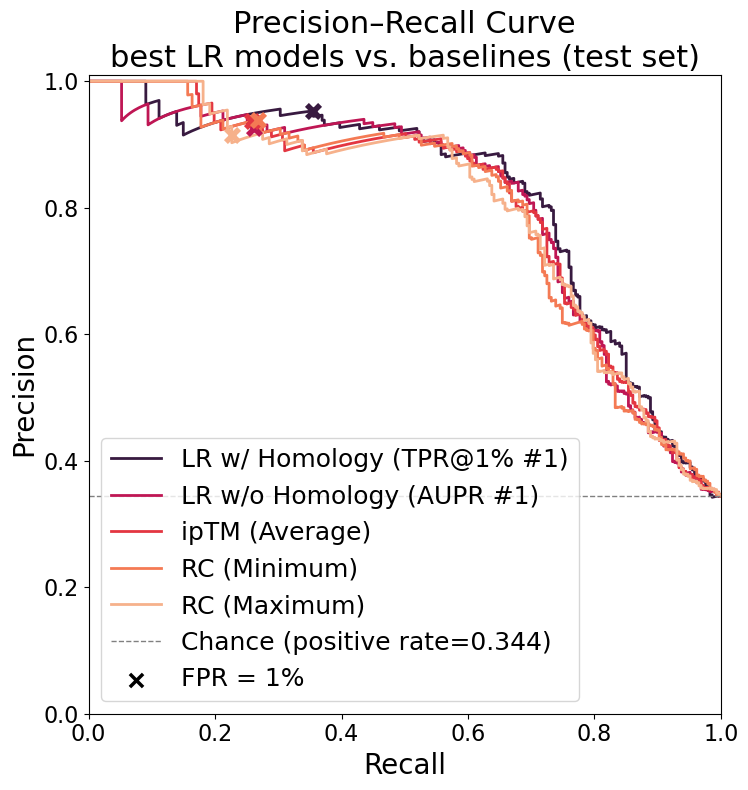

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [ ]:
import seaborn as sns
import numpy as np

# ── Precision–recall curve: best LR models vs. baselines (test set) ───────────
pr_curve_specs = [
    (best_with_name,    f"{best_with_name_minus_k}"),
    (best_without_name, f"{best_without_name_minus_k}"),
    ("ipTM (Average)",  "ipTM (Average)"),
    ("RC (Minimum)",    "RC (Minimum)"),
    ("RC (Maximum)",    "RC (Maximum)"),
]

cmap = sns.color_palette("rocket", as_cmap=True)
fracs = [0.15, 0.47, 0.58, 0.72, 0.85]
palette = [cmap(x) for x in fracs]

target_fpr = 0.01

fig, ax = plt.subplots(figsize=(8, 8))
for (key, plot_label), color in zip(pr_curve_specs, palette):
    prec, rec, _ = precision_recall_curve(y_test, scores[key])
    aupr = all_metrics[key]["aupr"]
    ax.plot(rec, prec, label=f"{plot_label}", linewidth=2, color=color)

    recall_at_fpr = tpr_at_fpr(y_test, scores[key], target_fpr)
    sort_idx = np.argsort(rec)
    precision_at_fpr = np.interp(recall_at_fpr, rec[sort_idx], prec[sort_idx])

    ax.scatter(recall_at_fpr, precision_at_fpr, marker="x", s=90,
               color=color, linewidths=4.0, zorder=5)

pos_rate = float(y_test.mean())
ax.axhline(pos_rate, color="grey", linestyle="--", linewidth=1,
           label=f"Chance (positive rate={pos_rate:.3f})")

ax.scatter([], [], marker="x", s=90, color="black", linewidths=2.5, label="FPR = 1%")

ax.set_aspect('equal', adjustable='box')
ax.set_xlabel("Recall", fontsize=20)
ax.set_ylabel("Precision", fontsize=20)
ax.set_title("Precision–Recall Curve\nbest LR models vs. baselines (test set)", fontsize=22)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.tick_params(axis='both', labelsize=16)
ax.legend(loc="lower left", fontsize=18)
fig.tight_layout()
plt.show()
# logistic_regression_baselines_v1_060726.pdf.png
fig.savefig("logistic_regression_baselines_v4_110726.pdf", bbox_inches="tight")
fig.savefig("logistic_regression_baselines_v4_110726.eps", bbox_inches="tight")
fig.savefig("logistic_regression_baselines_v4_110726.tiff", bbox_inches="tight")

## CV (out-of-fold) best-MCC thresholds for the final LR models

Reports the decision threshold each headline model would use under
`threshold_method="best_mcc"` -- i.e. the cutoff that maximises MCC on
`cross_val_predict` out-of-fold probabilities over the pooled train+val
set (never the test set). Recomputed here directly via `fit_and_eval_test`
rather than read from the cached `.pkl` sweeps, since the sweep's
`fit_and_eval_cv` threshold uses a slightly different CV split/scaling
convention (shuffled `StratifiedKFold` + per-fold scaling inside a
`Pipeline`) than `fit_and_eval_test` (unshuffled fold split, scaler fit once
on the whole pool) -- this cell matches whatever the manuscript table above
actually used.

In [13]:
# CV (train+val pool) best-MCC thresholds -- never touches the test set to
# pick anything; only used here to report the cutoff each model settled on.
cv_best_mcc_thresholds = {}

for label, feats in without_homology_candidates.items():
    rt = fit_and_eval_test(feats, label, eval_C=without_homology_C[label])
    cv_best_mcc_thresholds[label] = rt["threshold"]

for label, feats in with_homology_candidates.items():
    rt = fit_and_eval_test(feats, label, eval_C=with_homology_C[label])
    cv_best_mcc_thresholds[label] = rt["threshold"]

print("CV (train+val pool) best-MCC thresholds:\n")
for label, thr in cv_best_mcc_thresholds.items():
    print(f"  {label:<60}  threshold={thr:.4f}")


CV (train+val pool) best-MCC thresholds:

  LR w/o Homology (AUPR #1, k=8)                                threshold=0.5344
  LR w/o Homology (TPR@1% #1, k=3)                              threshold=0.5187
  LR w/ Homology (AUPR #1, k=10)                                threshold=0.5815
  LR w/ Homology (TPR@1% #1, k=13)                              threshold=0.5678


## Final production models — refit on all labeled data

Feature set, subset size, and regularization strength for both headline
models (`best_without_name` / `best_with_name`) are already frozen by the
CV-based selection and test-set evaluation above. With no further selection
decisions left to protect a held-out set from, both models are refit here on
every labeled row (train + test pooled, i.e. all of `df`), and each fitted
`StandardScaler` + `LogisticRegression` pipeline is saved to disk with its
feature list and C for later reuse.


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL PRODUCTION MODELS — refit on ALL labeled data (train + test pooled)
# Feature set, k, and C for both headline models are already frozen by the
# CV-based selection and test-set evaluation above; refitting on every row
# simply uses all available data now that no further selection decisions
# remain to be protected from test-set leakage.
# ══════════════════════════════════════════════════════════════════════════════
import joblib
from pathlib import Path

final_model_specs = [
    ("lr_without_homology", best_without_name,
     without_homology_candidates[best_without_name], without_homology_C[best_without_name]),
    ("lr_with_homology", best_with_name,
     with_homology_candidates[best_with_name], with_homology_C[best_with_name]),
]

final_models = {}
for tag, label, features, C in final_model_specs:
    X_full = df[features].values.astype(float)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(C=C, class_weight="balanced",
                                      solver="lbfgs", max_iter=2000, random_state=SEED)),
    ])
    pipe.fit(X_full, y)

    out_path = Path(f"{tag}.joblib")
    joblib.dump({
        "label":     label,
        "features":  features,
        "C":         C,
        "pipeline":  pipe,
        "n_samples": int(len(y)),
    }, out_path)

    final_models[tag] = pipe
    print(f"Saved {label}  ({len(features)} features, C={C:.5g}, "
          f"n={len(y)} rows) -> {out_path}")


Saved LR w/o Homology (AUPR #1, k=8)  (8 features, C=0.00026367, n=2083 rows) -> lr_without_homology.joblib
Saved LR w/ Homology (TPR@1% #1, k=13)  (13 features, C=1, n=2083 rows) -> lr_with_homology.joblib
